# RF Radio Map Reconstruction — Ablation Study

**Models evaluated:** CNN · RadioWNet (W-Net / U-Net) · ConvMAE · PartialConvMAE

**Dataset:** Sionna RT–generated 256×256 radio-propagation maps stored as Parquet files.

**Metrics:** MSE · RMSE · MAE · SSIM · Inference Latency (ms) · Throughput (samples/s)

**Purpose:** Select the best model for deployment in an AGV (Automated Guided Vehicle) real-time RF-map reconstruction pipeline.

---
**Dataset layout**
```
/content/drive/MyDrive/Senior Design/dataset_256/
├── ~train/
│   ├── train/       (~10 000 parquet files)
│   ├── train 2/     (~10 000 parquet files)
│   ├── train 3/     (~10 000 parquet files)
│   └── train 4/     (~10 000 parquet files)
├── val/             (~5 000 parquet files)
└── test/            (~5 000 parquet files)
```

Each `.parquet` file contains one row with columns: `building_mask`, `tx_origin`, `path_loss` (each a flat 256×256 array).

## 1 · Mount Google Drive & GPU Check

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import subprocess, torch
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

Fri May 15 00:02:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2 · Install Dependencies

In [ ]:
!pip install pyarrow pandas seaborn scikit-image torchmetrics -q
# pytorch-msssim for SSIM
!pip install pytorch-msssim -q
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.3 MB/s eta 0:00:00
Dependencies installed.


## 3 · Global Configuration

> **Edit the values in this cell to control dataset size, training length, and batch size.**

In [ ]:
import os

# ══════════════════════════════════════════════════════════════
#  DATASET PATHS
# ══════════════════════════════════════════════════════════════
BASE_DIR   = '/content/drive/MyDrive/Senior Design/dataset_256'
TRAIN_DIRS = [
    os.path.join(BASE_DIR, '~train', 'train'),
    os.path.join(BASE_DIR, '~train', 'train 2'),
    os.path.join(BASE_DIR, '~train', 'train 3'),
    os.path.join(BASE_DIR, '~train', 'train 4'),
]
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# ══════════════════════════════════════════════════════════════
#  DATASET SIZE (set to None to use all files)
# ══════════════════════════════════════════════════════════════
MAX_TRAIN  = 10000   # e.g. 5000 | 10000 | 20000 | None (all ~40k)
MAX_VAL    = 2000
MAX_TEST   = 2000

# ══════════════════════════════════════════════════════════════
#  NORMALISATION RANGE (path_loss in dB)
# ══════════════════════════════════════════════════════════════
MIN_DB = 30.0
MAX_DB = 140.0

# Sparse-sensor sampling (fraction of known pixels fed to models that need it)
SPARSE_LOW  = 655    # ~1% of 256×256
SPARSE_HIGH = 6553   # ~10%

# ══════════════════════════════════════════════════════════════
#  TRAINING HYPERPARAMETERS
# ══════════════════════════════════════════════════════════════
EPOCHS      = 30
BATCH_SIZE  = 32    # reduce to 16 if OOM
NUM_WORKERS = 2
LR          = 1e-4
PATIENCE    = 7     # early-stopping patience
IMG_SIZE    = 256
RANDOM_SEED = 42

# ══════════════════════════════════════════════════════════════
#  OUTPUT / CHECKPOINT DIRECTORY
# ══════════════════════════════════════════════════════════════
CKPT_DIR = '/content/drive/MyDrive/Senior Design/checkpoints/ablation'
os.makedirs(CKPT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  MODEL COLOURS (used throughout all plots)
# ══════════════════════════════════════════════════════════════
MODEL_COLORS = {
    'CNN'           : '#4C72B0',
    'WNet'          : '#DD8452',
    'ConvMAE'       : '#55A868',
    'PartialConvMAE': '#C44E52',
}

print('Configuration loaded.')
print(f'  Train dirs  : {len(TRAIN_DIRS)} partitions')
print(f'  Max train   : {MAX_TRAIN}  |  val: {MAX_VAL}  |  test: {MAX_TEST}')
print(f'  Epochs      : {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}')
print(f'  Checkpoints : {CKPT_DIR}')

Configuration loaded.
  Train dirs  : 4 partitions
  Max train   : 10000  |  val: 2000  |  test: 2000
  Epochs      : 30  |  Batch: 32  |  LR: 0.0001
  Checkpoints : /content/drive/MyDrive/Senior Design/checkpoints/ablation


## 4 · Shared Dataset — Parquet Loader

In [ ]:
import glob, random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── gather all parquet paths ─────────────────────────────────
def collect_files(dirs, limit=None):
    files = []
    if isinstance(dirs, str):
        dirs = [dirs]
    for d in dirs:
        found = sorted(glob.glob(os.path.join(d, '*.parquet')))
        files.extend(found)
    random.shuffle(files)
    return files[:limit] if limit else files

train_files = collect_files(TRAIN_DIRS, MAX_TRAIN)
val_files   = collect_files(VAL_DIR,    MAX_VAL)
test_files  = collect_files(TEST_DIR,   MAX_TEST)

print(f'Files — train: {len(train_files)} | val: {len(val_files)} | test: {len(test_files)}')

# ── Dataset ──────────────────────────────────────────────────
class RadioMapDataset(Dataset):
    """
    Returns (inputs, target) where:
      inputs  : FloatTensor (3, H, W)  — [building_mask, tx_origin, sparse_path_loss_norm]
      target  : FloatTensor (1, H, W)  — normalised full path_loss

    Building mask and tx_origin are binary maps (0/1 float).
    Path loss is normalised to [0,1] via (x - MIN_DB)/(MAX_DB - MIN_DB).
    Sparse samples use a random 1%–10% subset of the ground-truth pixels.
    """
    def __init__(self, file_list, min_db=MIN_DB, max_db=MAX_DB,
                 sparse_low=SPARSE_LOW, sparse_high=SPARSE_HIGH,
                 h=IMG_SIZE, w=IMG_SIZE):
        self.files       = file_list
        self.min_db      = min_db
        self.max_db      = max_db
        self.sparse_low  = sparse_low
        self.sparse_high = sparse_high
        self.h, self.w   = h, w

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        df  = pd.read_parquet(self.files[idx], engine='pyarrow')
        row = df.iloc[0]

        env_map   = np.array(row['building_mask'], dtype=np.float32).reshape(self.h, self.w)
        tx_map    = np.array(row['tx_origin'],     dtype=np.float32).reshape(self.h, self.w)
        radio_map = np.array(row['path_loss'],     dtype=np.float32).reshape(self.h, self.w)

        # Normalise radio map
        radio_norm = (radio_map - self.min_db) / (self.max_db - self.min_db)
        radio_norm = np.clip(radio_norm, 0.0, 1.0)

        # Sparse sensor simulation
        n_samples = np.random.randint(self.sparse_low, self.sparse_high)
        xs = np.random.randint(0, self.w, size=n_samples)
        ys = np.random.randint(0, self.h, size=n_samples)
        sparse = np.zeros((self.h, self.w), dtype=np.float32)
        sparse[ys, xs] = radio_norm[ys, xs]

        inputs = np.stack([env_map, tx_map, sparse], axis=0)
        target = np.expand_dims(radio_norm, axis=0)

        return torch.from_numpy(inputs), torch.from_numpy(target)


train_ds = RadioMapDataset(train_files)
val_ds   = RadioMapDataset(val_files)
test_ds  = RadioMapDataset(test_files)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders ready.')

# ── sanity-check one batch ────────────────────────────────────
inp, tgt = next(iter(train_loader))
print(f'Input shape : {inp.shape}  dtype: {inp.dtype}')
print(f'Target shape: {tgt.shape}  min: {tgt.min():.3f}  max: {tgt.max():.3f}')

Files — train: 10000 | val: 2000 | test: 2000
DataLoaders ready.
Input shape : torch.Size([32, 3, 256, 256])  dtype: torch.float32
Target shape: torch.Size([32, 1, 256, 256])  min: 0.104  max: 1.000


## 5 · Visualise a Sample from the Dataset

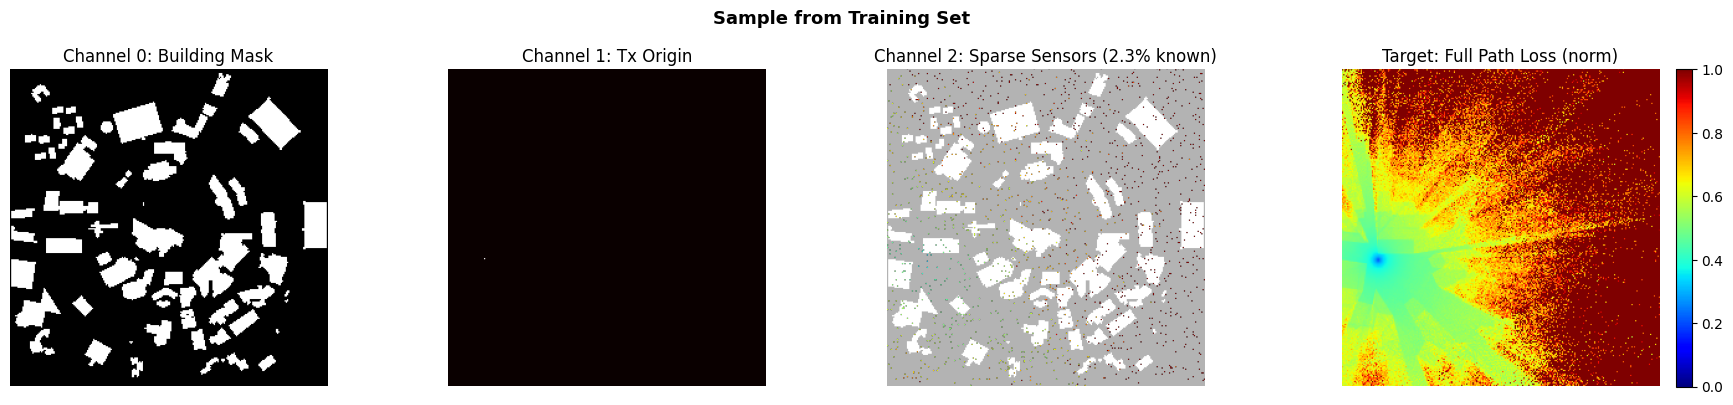

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sample_inp, sample_tgt = train_ds[0]
inp_np = sample_inp.numpy()
tgt_np = sample_tgt.numpy()[0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(inp_np[0], cmap='gray');  axes[0].set_title('Channel 0: Building Mask'); axes[0].axis('off')
axes[1].imshow(inp_np[1], cmap='hot');   axes[1].set_title('Channel 1: Tx Origin');     axes[1].axis('off')
sparse_disp = np.ma.masked_where(inp_np[2] == 0, inp_np[2])
axes[2].imshow(inp_np[0], cmap='gray', alpha=0.3)
im = axes[2].imshow(sparse_disp, cmap='jet', vmin=0, vmax=1)
pct = (np.count_nonzero(inp_np[2]) / (IMG_SIZE**2)) * 100
axes[2].set_title(f'Channel 2: Sparse Sensors ({pct:.1f}% known)'); axes[2].axis('off')
im2 = axes[3].imshow(tgt_np, cmap='jet', vmin=0, vmax=1)
axes[3].set_title('Target: Full Path Loss (norm)'); axes[3].axis('off')
plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
plt.suptitle('Sample from Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'sample_visualisation.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6 · Model Definitions
### 6a · Shared Utilities

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import time, copy
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def ema(v, alpha=0.3):
    out = np.empty_like(v, dtype=float)
    out[0] = v[0]
    for i in range(1, len(v)):
        out[i] = alpha * v[i] + (1 - alpha) * out[i - 1]
    return out

Device: cuda


### 6b · CNN

In [ ]:
class SpectrumCNN(nn.Module):
    """
    Simple encoder-decoder CNN for radio-map reconstruction.
    Input  : (B, 3, H, W)  — building_mask + tx_origin + sparse_path_loss
    Output : (B, 1, H, W)  — dense path_loss estimate
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)  # 128
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)  # 64
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2)  # 32
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        # Decoder
        self.up3   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3  = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.up2   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2  = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.up1   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1  = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head  = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(self.up3(b))
        d2 = self.dec2(self.up2(d3))
        d1 = self.dec1(self.up1(d2))
        return self.head(d1)

cnn_model = SpectrumCNN().to(device)
print(f'CNN  — params: {count_params(cnn_model):,}')

CNN  — params: 1,561,953


### 6c · RadioWNet (W-Net / double U-Net)

In [ ]:
def convrelu(in_ch, out_ch, k, pad, pool):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, k, padding=pad),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(pool, stride=pool),
    )

def convreluT(in_ch, out_ch, k, pad):
    return nn.Sequential(
        nn.ConvTranspose2d(in_ch, out_ch, k, stride=2, padding=pad),
        nn.ReLU(inplace=True),
    )


class RadioWNet(nn.Module):
    """
    Double U-Net (W-Net) for radio-map reconstruction.
    Phase 'full' trains both U-Nets end-to-end and returns [output1, output2].
    Input  : (B, 3, 256, 256)
    Output : [(B,1,256,256), (B,1,256,256)] — coarse + refined
    """
    def __init__(self, inputs=3):
        super().__init__()
        # ── 1st U-Net ──────────────────────────────────────────────────
        self.layer00  = convrelu(inputs, 6, 3, 1, 1)
        self.layer0   = convrelu(6,  40, 5, 2, 2)
        self.layer1   = convrelu(40, 50, 5, 2, 2)
        self.layer10  = convrelu(50, 60, 5, 2, 1)
        self.layer2   = convrelu(60, 100, 5, 2, 2)
        self.layer20  = convrelu(100,100, 3, 1, 1)
        self.layer3   = convrelu(100,150, 5, 2, 2)
        self.layer4   = convrelu(150,300, 5, 2, 2)
        self.layer5   = convrelu(300,500, 5, 2, 2)
        self.conv_up5  = convreluT(500,  300, 4, 1)
        self.conv_up4  = convreluT(600,  150, 4, 1)
        self.conv_up3  = convreluT(300,  100, 4, 1)
        self.conv_up20 = convrelu( 200,  100, 3, 1, 1)
        self.conv_up2  = convreluT(200,   60, 6, 2)
        self.conv_up10 = convrelu( 120,   50, 5, 2, 1)
        self.conv_up1  = convreluT(100,   40, 6, 2)
        self.conv_up0  = convreluT( 80,   20, 6, 2)
        self.conv_up00 = convrelu(20+6+inputs, 20, 5, 2, 1)
        self.conv_up000= convrelu(20+inputs,    1, 5, 2, 1)
        # ── 2nd U-Net ──────────────────────────────────────────────────
        self.Wlayer00  = convrelu(inputs+1, 20, 3, 1, 1)
        self.Wlayer0   = convrelu(20, 30, 5, 2, 2)
        self.Wlayer1   = convrelu(30, 40, 5, 2, 2)
        self.Wlayer10  = convrelu(40, 50, 5, 2, 1)
        self.Wlayer2   = convrelu(50, 60, 5, 2, 2)
        self.Wlayer20  = convrelu(60, 70, 3, 1, 1)
        self.Wlayer3   = convrelu(70,  90, 5, 2, 2)
        self.Wlayer4   = convrelu(90, 110, 5, 2, 2)
        self.Wlayer5   = convrelu(110,150, 5, 2, 2)
        self.Wconv_up5  = convreluT(150, 110, 4, 1)
        self.Wconv_up4  = convreluT(220,  90, 4, 1)
        self.Wconv_up3  = convreluT(180,  70, 4, 1)
        self.Wconv_up20 = convrelu( 140,  60, 3, 1, 1)
        self.Wconv_up2  = convreluT(120,  50, 6, 2)
        self.Wconv_up10 = convrelu( 100,  40, 5, 2, 1)
        self.Wconv_up1  = convreluT( 80,  30, 6, 2)
        self.Wconv_up0  = convreluT( 60,  20, 6, 2)
        self.Wconv_up00 = convrelu(20+20+inputs+1, 20, 5, 2, 1)
        self.Wconv_up000= convrelu(20+inputs+1,     1, 5, 2, 1)

    def _unet1(self, x):
        l00 = self.layer00(x)
        l0  = self.layer0(l00)
        l1  = self.layer1(l0)
        l10 = self.layer10(l1)
        l2  = self.layer2(l10)
        l20 = self.layer20(l2)
        l3  = self.layer3(l20)
        l4  = self.layer4(l3)
        l5  = self.layer5(l4)
        u = self.conv_up5(l5)
        u = self.conv_up4(torch.cat([u, l4], 1))
        u = self.conv_up3(torch.cat([u, l3], 1))
        u = self.conv_up20(torch.cat([u, l20], 1))
        u = self.conv_up2(torch.cat([u, l2], 1))
        u = self.conv_up10(torch.cat([u, l10], 1))
        u = self.conv_up1(torch.cat([u, l1], 1))
        u = self.conv_up0(torch.cat([u, l0], 1))
        u = torch.cat([u, l00, x], 1)
        u = self.conv_up00(u)
        u = self.conv_up000(torch.cat([u, x], 1))
        return u, l00

    def _unet2(self, wx):
        l00 = self.Wlayer00(wx)
        l0  = self.Wlayer0(l00)
        l1  = self.Wlayer1(l0)
        l10 = self.Wlayer10(l1)
        l2  = self.Wlayer2(l10)
        l20 = self.Wlayer20(l2)
        l3  = self.Wlayer3(l20)
        l4  = self.Wlayer4(l3)
        l5  = self.Wlayer5(l4)
        u = self.Wconv_up5(l5)
        u = self.Wconv_up4(torch.cat([u, l4], 1))
        u = self.Wconv_up3(torch.cat([u, l3], 1))
        u = self.Wconv_up20(torch.cat([u, l20], 1))
        u = self.Wconv_up2(torch.cat([u, l2], 1))
        u = self.Wconv_up10(torch.cat([u, l10], 1))
        u = self.Wconv_up1(torch.cat([u, l1], 1))
        u = self.Wconv_up0(torch.cat([u, l0], 1))
        u = torch.cat([u, l00, wx], 1)
        u = self.Wconv_up00(u)
        u = self.Wconv_up000(torch.cat([u, wx], 1))
        return u

    def forward(self, x):
        out1, _ = self._unet1(x)
        wx = torch.cat([out1, x], 1)
        out2 = self._unet2(wx)
        return out1, out2

wnet_model = RadioWNet(inputs=3).to(device)
print(f'WNet — params: {count_params(wnet_model):,}')

WNet — params: 13,275,315


### 6d · ConvMAE (fine-tune head on top of pre-trained encoder)

> ConvMAE pre-training uses the original repo. Here we attach a lightweight dense-prediction decoder for supervised fine-tuning on path-loss reconstruction.

In [ ]:
import sys, collections.abc

# ── clone repo if needed ──────────────────────────────────────
REPO_DIR = '/content/ConvMAE'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Alpha-VL/ConvMAE.git {REPO_DIR} -q
else:
    print('ConvMAE repo already present.')

# ── compatibility patches ─────────────────────────────────────
!pip uninstall timm -y -q && pip install timm==0.3.2 einops -q
if not hasattr(torch, '_six'):
    class _Six:
        container_abcs = collections.abc
    sys.modules['torch._six'] = _Six()

!sed -i 's/np\.float\b/np.float32/g'           {REPO_DIR}/util/pos_embed.py
!sed -i 's/torch.cuda.amp.GradScaler()/torch.amp.GradScaler("cuda")/g' {REPO_DIR}/util/misc.py
!sed -i "s/torch.cuda.amp.autocast()/torch.amp.autocast('cuda')/g"    {REPO_DIR}/engine_pretrain.py
!sed -i 's/from torch._six import inf/from math import inf/g'          {REPO_DIR}/util/misc.py
print('Patches applied.')

sys.path.insert(0, REPO_DIR)
import models_convmae
import timm
print('timm:', timm.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 8.5 MB/s eta 0:00:00
Patches applied.
timm: 0.3.2


In [ ]:
class ConvMAEDecoder(nn.Module):
    """
    Lightweight dense-prediction decoder that wraps the ConvMAE ViT encoder.
    The MAE masking is disabled (mask_ratio=0) so all patches are encoded.
    Encoded tokens are reshaped and progressively upsampled to (B,1,H,W).
    """
    def __init__(self, enc_dim=768, patch_size=16, img_size=256):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size  = img_size // patch_size  # 14 if img_size=224
        # Project encoder dim → decoder channels
        self.proj = nn.Conv2d(enc_dim, 256, 1)
        # Progressive upsampling
        self.up1  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.up3  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
        )
        self.up4  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1), nn.BatchNorm2d(16), nn.GELU(),
        )
        self.head = nn.Conv2d(16, 1, 1)

    def forward(self, tokens):
        # tokens: (B, N, C)  where N = grid_size^2
        B, N, C = tokens.shape
        g = self.grid_size
        x = tokens.transpose(1, 2).reshape(B, C, g, g)
        x = self.proj(x)
        x = self.up1(x)   # 32
        x = self.up2(x)   # 64
        x = self.up3(x)   # 128
        x = self.up4(x)   # 256
        return self.head(x)


class ConvMAEReconstructor(nn.Module):
    """
    ConvMAE encoder + dense-prediction decoder.
    Input : (B, 3, 256, 256)
    Output: (B, 1, 256, 256)
    """
    def __init__(self):
        super().__init__()
        self.encoder = models_convmae.__dict__['convmae_convvit_base_patch16']()
        # Remove the original MAE decoder head — we add our own
        enc_dim = 768
        # The encoder expects 224x224, so the decoder must expect 224x224
        # to construct the correct grid size (14x14) for the tokens.
        self.decoder = ConvMAEDecoder(enc_dim=enc_dim, patch_size=16, img_size=224)

    def forward(self, x):
        # 1. Resize input from 256x256 to 224x224 for the ConvMAE encoder
        x_224 = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        # 2. Forward through encoder with mask_ratio=0 (no masking)
        latent, _, _ = self.encoder.forward_encoder(x_224, mask_ratio=0.0)

        # latent: (B, N, C) — there is no CLS token in ConvMAE's output
        tokens = latent

        # 3. Decode back to 224x224 spatial map
        out_224 = self.decoder(tokens)

        # 4. Resize output back to original 256x256 resolution
        out_256 = F.interpolate(out_224, size=(256, 256), mode='bilinear', align_corners=False)
        return out_256

convmae_model = ConvMAEReconstructor().to(device)
print(f'ConvMAE — params: {count_params(convmae_model):,}')

ConvMAE — params: 115,379,809


### 6e · PartialConvMAE

In [ ]:
class PartialConv2d(nn.Module):
    """
    Partial convolution layer that re-normalises by the ratio of valid pixels.
    Used to handle masked (unknown) regions in the input.
    """
    def __init__(self, in_ch, out_ch, k, stride=1, padding=0, bias=True):
        super().__init__()
        self.conv   = nn.Conv2d(in_ch, out_ch, k, stride=stride, padding=padding, bias=False)
        self.weight_sum = nn.Conv2d(in_ch, out_ch, k, stride=stride, padding=padding, bias=False)
        # Mask convolution: all ones to count valid pixels
        nn.init.constant_(self.weight_sum.weight, 1.0)
        for p in self.weight_sum.parameters():
            p.requires_grad = False
        if bias:
            self.bias = nn.Parameter(torch.zeros(1, out_ch, 1, 1))
        else:
            self.bias = None
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x, mask):
        # x: feature map, mask: binary (1=valid, 0=unknown)
        masked_x   = x * mask
        raw_out    = self.conv(masked_x)
        norm_scale = self.weight_sum(mask)
        norm_scale = torch.clamp(norm_scale, min=1e-6)
        out = raw_out / norm_scale
        if self.bias is not None:
            out = out + self.bias
        out = self.bn(out)
        # Update mask: output pixel valid if ≥1 input pixel was valid
        new_mask = (norm_scale > 0).float()
        return out, new_mask


class PartialConvMAE(nn.Module):
    """
    Partial-Conv UNet for radio-map reconstruction from sparse sensor inputs.
    Uses partial convolutions in the encoder to handle masked (unknown) regions.
    Input : (B, 3, 256, 256)  — [building_mask, tx_origin, sparse_path_loss_norm]
    Output: (B, 1, 256, 256)  — dense path_loss
    """
    def __init__(self):
        super().__init__()
        # Partial-conv encoder (mask propagates through)
        self.pconv1 = PartialConv2d(3,   32, 3, padding=1)
        self.act1   = nn.ReLU(inplace=True)
        self.pool1  = nn.MaxPool2d(2)   # 128

        self.pconv2 = PartialConv2d(32,  64, 3, padding=1)
        self.act2   = nn.ReLU(inplace=True)
        self.pool2  = nn.MaxPool2d(2)   # 64

        self.pconv3 = PartialConv2d(64, 128, 3, padding=1)
        self.act3   = nn.ReLU(inplace=True)
        self.pool3  = nn.MaxPool2d(2)   # 32

        # Standard bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # Standard decoder (skip connections from partial-conv encoder)
        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(256+128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128+64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64+32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # Derive mask from sparse channel: 1 where sensor data present
        mask = (x[:, 2:3, :, :] > 0).float()
        mask_in = mask.expand(-1, 3, -1, -1)

        e1, m1 = self.pconv1(x, mask_in)
        e1 = self.act1(e1)
        e1_pool = self.pool1(e1)
        m1_pool = self.pool1(m1)

        e2, m2 = self.pconv2(e1_pool, m1_pool)
        e2 = self.act2(e2)
        e2_pool = self.pool2(e2)
        m2_pool = self.pool2(m2)

        e3, m3 = self.pconv3(e2_pool, m2_pool)
        e3 = self.act3(e3)
        e3_pool = self.pool3(e3)

        b = self.bottleneck(e3_pool)

        d3 = self.dec3(torch.cat([self.up3(b), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.head(d1)

pconv_model = PartialConvMAE().to(device)
print(f'PartialConvMAE — params: {count_params(pconv_model):,}')

PartialConvMAE — params: 1,561,281


## 7 · Shared Training Engine

In [ ]:
from pytorch_msssim import ssim as compute_ssim

def compute_metrics_batch(preds, targets):
    """Returns dict of per-batch scalar metrics (all on CPU)."""
    # Ensure tensors are float32 to avoid issues with SSIM under AMP
    preds = preds.float()
    targets = targets.float()

    mse  = F.mse_loss(preds, targets).item()
    mae  = F.l1_loss(preds, targets).item()
    rmse = mse ** 0.5
    # SSIM expects values in [0,1]
    p_c  = torch.clamp(preds,   0, 1)
    t_c  = torch.clamp(targets, 0, 1)
    ssim_val = compute_ssim(p_c, t_c, data_range=1.0, size_average=True).item()
    return {'mse': mse, 'mae': mae, 'rmse': rmse, 'ssim': ssim_val}


def run_epoch(model, loader, optimizer, scaler, phase, device,
              wnet_phase=None):
    """
    Run one training or validation epoch.
    wnet_phase: 'first' | 'second' | 'full' — controls RadioWNet gradient flow.
    Returns dict of mean metrics.
    """
    is_train = phase == 'train'
    model.train() if is_train else model.eval()

    totals = defaultdict(float)
    n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for inp, tgt in loader:
            inp, tgt = inp.to(device, non_blocking=True), tgt.to(device, non_blocking=True)
            bs = inp.size(0)

            if is_train:
                optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                # ── WNet: train both U-Nets jointly ──────────────────────
                if wnet_phase is not None:
                    out1, out2 = model(inp)
                    loss1 = F.mse_loss(out1, tgt)
                    loss2 = F.mse_loss(out2, tgt)
                    loss  = loss1 + loss2           # joint loss
                    preds = out2                    # report refined output
                else:
                    preds = model(inp)
                    loss  = F.mse_loss(preds, tgt)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            m = compute_metrics_batch(preds.detach(), tgt)
            for k, v in m.items():
                totals[k] += v * bs
            totals['loss'] += loss.item() * bs
            n += bs

    return {k: v / n for k, v in totals.items()}


def train_model(name, model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, patience=PATIENCE,
                wnet_phase=None):
    """
    Full training loop with early stopping, AMP, cosine LR schedule.
    Returns (best_model, history_dict).
    """
    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)
    scaler     = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    history    = defaultdict(list)
    best_val   = float('inf')
    no_improve = 0
    best_state = None
    ckpt_path  = os.path.join(CKPT_DIR, f'{name}_best.pth')

    print(f'\n{'='*60}')
    print(f'  Training {name}  |  {count_params(model)/1e6:.2f}M params  |  {epochs} epochs')
    print(f'{'='*60}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, optimizer, scaler, 'train', device, wnet_phase)
        va = run_epoch(model, val_loader,   optimizer, scaler, 'val',   device, wnet_phase)
        scheduler.step()

        for k, v in tr.items(): history[f'train_{k}'].append(v)
        for k, v in va.items(): history[f'val_{k}'].append(v)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        elapsed = time.time() - t0
        print(f'Ep {epoch:03d}/{epochs} | '
              f'tr_loss={tr["loss"]:.5f} va_loss={va["loss"]:.5f} | '
              f'va_rmse={va["rmse"]:.4f} va_ssim={va["ssim"]:.4f} | '
              f'{elapsed:.1f}s')

        # Save CSV snapshot each epoch
        pd.DataFrame(history).to_csv(
            os.path.join(CKPT_DIR, f'{name}_history.csv'), index=False)

        if va['loss'] < best_val:
            best_val   = va['loss']
            no_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            print(f'  ✓ New best val loss: {best_val:.6f}')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch} (no improvement for {patience} epochs).')
                break

    model.load_state_dict(best_state)
    print(f'  Best val MSE: {best_val:.6f}')
    return model, dict(history)

print('Training engine ready.')


Training engine ready.


## 8 · Train All Models

> Each model trains to completion with early stopping. If you only want to run one model, comment out the others.

In [ ]:
all_histories = {}

# ── CNN ──────────────────────────────────────────────────────
cnn_model, all_histories['CNN'] = train_model(
    'CNN', cnn_model, train_loader, val_loader)


  Training CNN  |  1.56M params  |  30 epochs
Ep 001/30 | tr_loss=0.02121 va_loss=0.00834 | va_rmse=0.0913 va_ssim=0.3452 | 6553.1s
  ✓ New best val loss: 0.008340
Ep 002/30 | tr_loss=0.00808 va_loss=0.00794 | va_rmse=0.0891 va_ssim=0.3524 | 130.0s
  ✓ New best val loss: 0.007942
Ep 003/30 | tr_loss=0.00775 va_loss=0.00745 | va_rmse=0.0863 va_ssim=0.3576 | 121.3s
  ✓ New best val loss: 0.007448
Ep 004/30 | tr_loss=0.00759 va_loss=0.00742 | va_rmse=0.0861 va_ssim=0.3604 | 122.3s
  ✓ New best val loss: 0.007423
Ep 005/30 | tr_loss=0.00748 va_loss=0.00732 | va_rmse=0.0855 va_ssim=0.3604 | 125.6s
  ✓ New best val loss: 0.007320
Ep 006/30 | tr_loss=0.00744 va_loss=0.00729 | va_rmse=0.0854 va_ssim=0.3633 | 124.6s
  ✓ New best val loss: 0.007294
Ep 007/30 | tr_loss=0.00738 va_loss=0.00741 | va_rmse=0.0861 va_ssim=0.3622 | 120.2s
Ep 008/30 | tr_loss=0.00731 va_loss=0.00729 | va_rmse=0.0854 va_ssim=0.3637 | 121.8s
  ✓ New best val loss: 0.007290
Ep 009/30 | tr_loss=0.00729 va_loss=0.00723 | va

In [ ]:
# ── RadioWNet ─────────────────────────────────────────────────
wnet_model, all_histories['WNet'] = train_model(
    'WNet', wnet_model, train_loader, val_loader, wnet_phase='full')


  Training WNet  |  13.28M params  |  30 epochs
Ep 001/30 | tr_loss=0.16215 va_loss=0.04146 | va_rmse=0.1381 va_ssim=0.2621 | 205.7s
  ✓ New best val loss: 0.041463
Ep 002/30 | tr_loss=0.02447 va_loss=0.01891 | va_rmse=0.0960 va_ssim=0.3356 | 205.2s
  ✓ New best val loss: 0.018908
Ep 003/30 | tr_loss=0.01765 va_loss=0.01776 | va_rmse=0.0930 va_ssim=0.3326 | 205.6s
  ✓ New best val loss: 0.017764
Ep 004/30 | tr_loss=0.01690 va_loss=0.01695 | va_rmse=0.0916 va_ssim=0.3421 | 205.5s
  ✓ New best val loss: 0.016946
Ep 005/30 | tr_loss=0.01621 va_loss=0.01613 | va_rmse=0.0891 va_ssim=0.3561 | 204.7s
  ✓ New best val loss: 0.016135
Ep 006/30 | tr_loss=0.01609 va_loss=0.01570 | va_rmse=0.0874 va_ssim=0.3534 | 205.1s
  ✓ New best val loss: 0.015699
Ep 007/30 | tr_loss=0.01572 va_loss=0.01534 | va_rmse=0.0868 va_ssim=0.3572 | 205.2s
  ✓ New best val loss: 0.015345
Ep 008/30 | tr_loss=0.01564 va_loss=0.01523 | va_rmse=0.0865 va_ssim=0.3587 | 205.1s
  ✓ New best val loss: 0.015227
Ep 009/30 | tr_

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

# ConvMAE is very large (115M+ params), so we need a smaller batch size
convmae_batch_size = 8

cm_train_loader = DataLoader(train_ds, batch_size=convmae_batch_size, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
cm_val_loader   = DataLoader(val_ds,   batch_size=convmae_batch_size, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── ConvMAE ───────────────────────────────────────────────────
convmae_model, all_histories['ConvMAE'] = train_model(
    'ConvMAE', convmae_model, cm_train_loader, cm_val_loader)


  Training ConvMAE  |  115.38M params  |  30 epochs
Ep 001/30 | tr_loss=0.03529 va_loss=0.02818 | va_rmse=0.1679 va_ssim=0.3179 | 256.8s
  ✓ New best val loss: 0.028184
Ep 002/30 | tr_loss=0.02826 va_loss=0.02778 | va_rmse=0.1667 va_ssim=0.3170 | 259.3s
  ✓ New best val loss: 0.027781
Ep 003/30 | tr_loss=0.02751 va_loss=0.02696 | va_rmse=0.1642 va_ssim=0.3190 | 259.5s
  ✓ New best val loss: 0.026960
Ep 004/30 | tr_loss=0.02704 va_loss=0.02680 | va_rmse=0.1637 va_ssim=0.3166 | 259.1s
  ✓ New best val loss: 0.026803
Ep 005/30 | tr_loss=0.02676 va_loss=0.02743 | va_rmse=0.1656 va_ssim=0.3160 | 262.7s
Ep 006/30 | tr_loss=0.02657 va_loss=0.02653 | va_rmse=0.1628 va_ssim=0.3165 | 253.4s
  ✓ New best val loss: 0.026528
Ep 007/30 | tr_loss=0.02641 va_loss=0.02637 | va_rmse=0.1624 va_ssim=0.3183 | 261.8s
  ✓ New best val loss: 0.026369
Ep 008/30 | tr_loss=0.02633 va_loss=0.02645 | va_rmse=0.1626 va_ssim=0.3190 | 265.8s
Ep 009/30 | tr_loss=0.02623 va_loss=0.02609 | va_rmse=0.1615 va_ssim=0.3187

In [ ]:
# ── PartialConvMAE ────────────────────────────────────────────
pconv_model, all_histories['PartialConvMAE'] = train_model(
    'PartialConvMAE', pconv_model, train_loader, val_loader)


  Training PartialConvMAE  |  1.56M params  |  30 epochs
Ep 001/30 | tr_loss=0.19748 va_loss=0.02901 | va_rmse=0.1703 va_ssim=0.2807 | 131.0s
  ✓ New best val loss: 0.029011
Ep 002/30 | tr_loss=0.01772 va_loss=0.00900 | va_rmse=0.0949 va_ssim=0.3184 | 120.0s
  ✓ New best val loss: 0.009003
Ep 003/30 | tr_loss=0.01351 va_loss=0.02515 | va_rmse=0.1586 va_ssim=0.2998 | 119.6s
Ep 004/30 | tr_loss=0.01187 va_loss=0.02053 | va_rmse=0.1433 va_ssim=0.3212 | 120.7s
Ep 005/30 | tr_loss=0.01032 va_loss=0.01537 | va_rmse=0.1239 va_ssim=0.3100 | 121.5s
Ep 006/30 | tr_loss=0.00978 va_loss=0.03005 | va_rmse=0.1733 va_ssim=0.2911 | 122.8s
Ep 007/30 | tr_loss=0.00893 va_loss=0.01429 | va_rmse=0.1195 va_ssim=0.3052 | 121.5s
Ep 008/30 | tr_loss=0.00916 va_loss=0.01139 | va_rmse=0.1067 va_ssim=0.3190 | 122.9s
Ep 009/30 | tr_loss=0.00882 va_loss=0.00957 | va_rmse=0.0978 va_ssim=0.3257 | 124.8s
  Early stop at epoch 9 (no improvement for 7 epochs).
  Best val MSE: 0.009003


## 9 · Per-Model Training Dashboards

/tmp/ipykernel_15519/2557079151.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


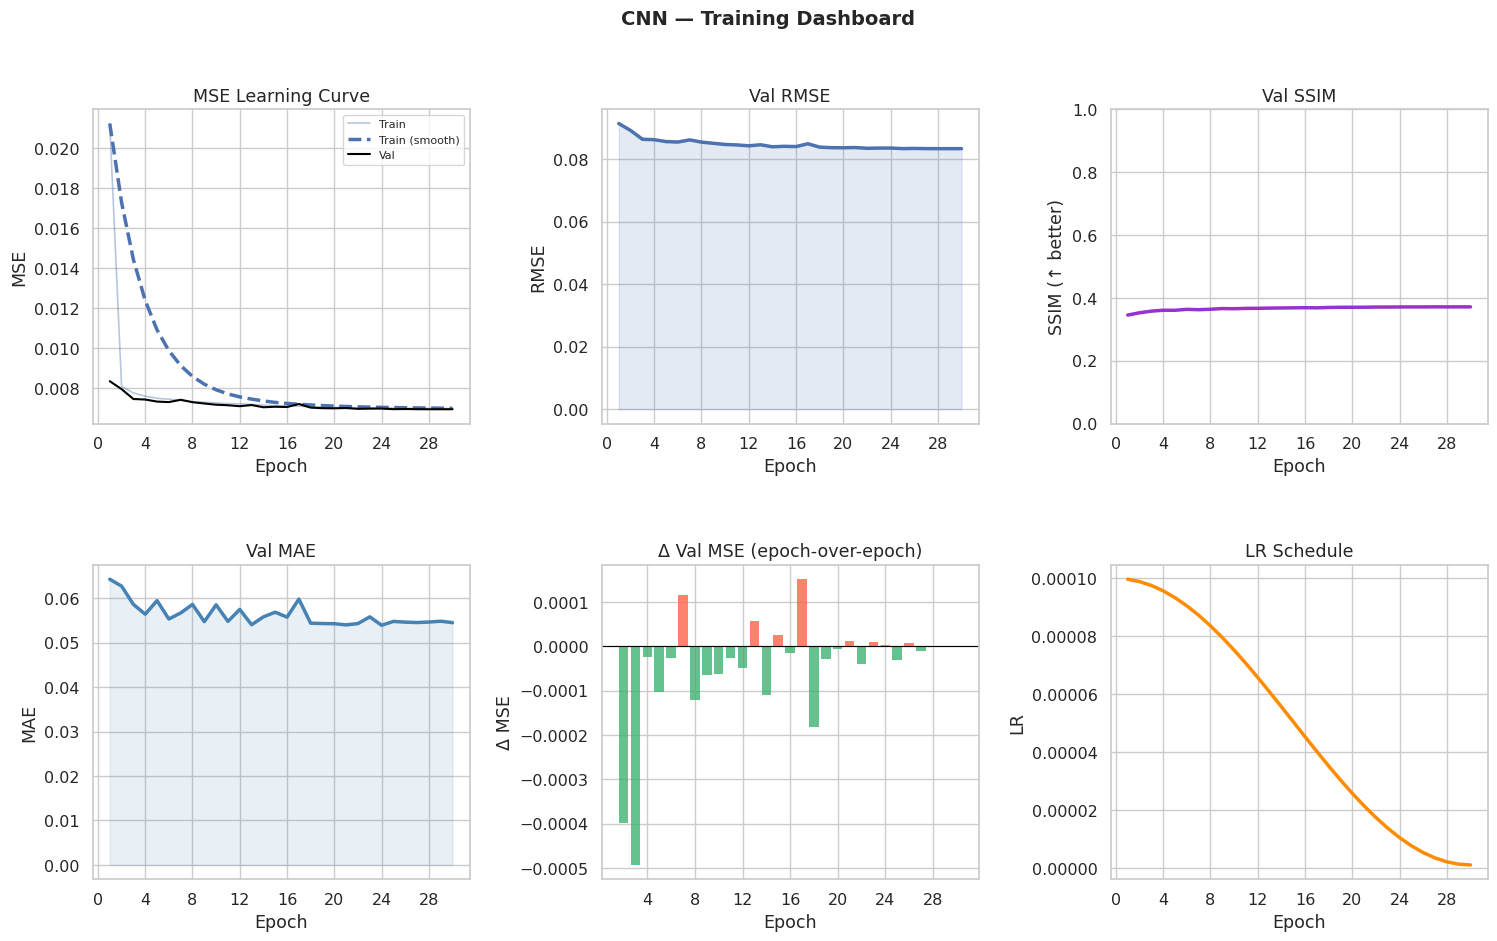

Saved: /content/drive/MyDrive/Senior Design/checkpoints/ablation/CNN_dashboard.png


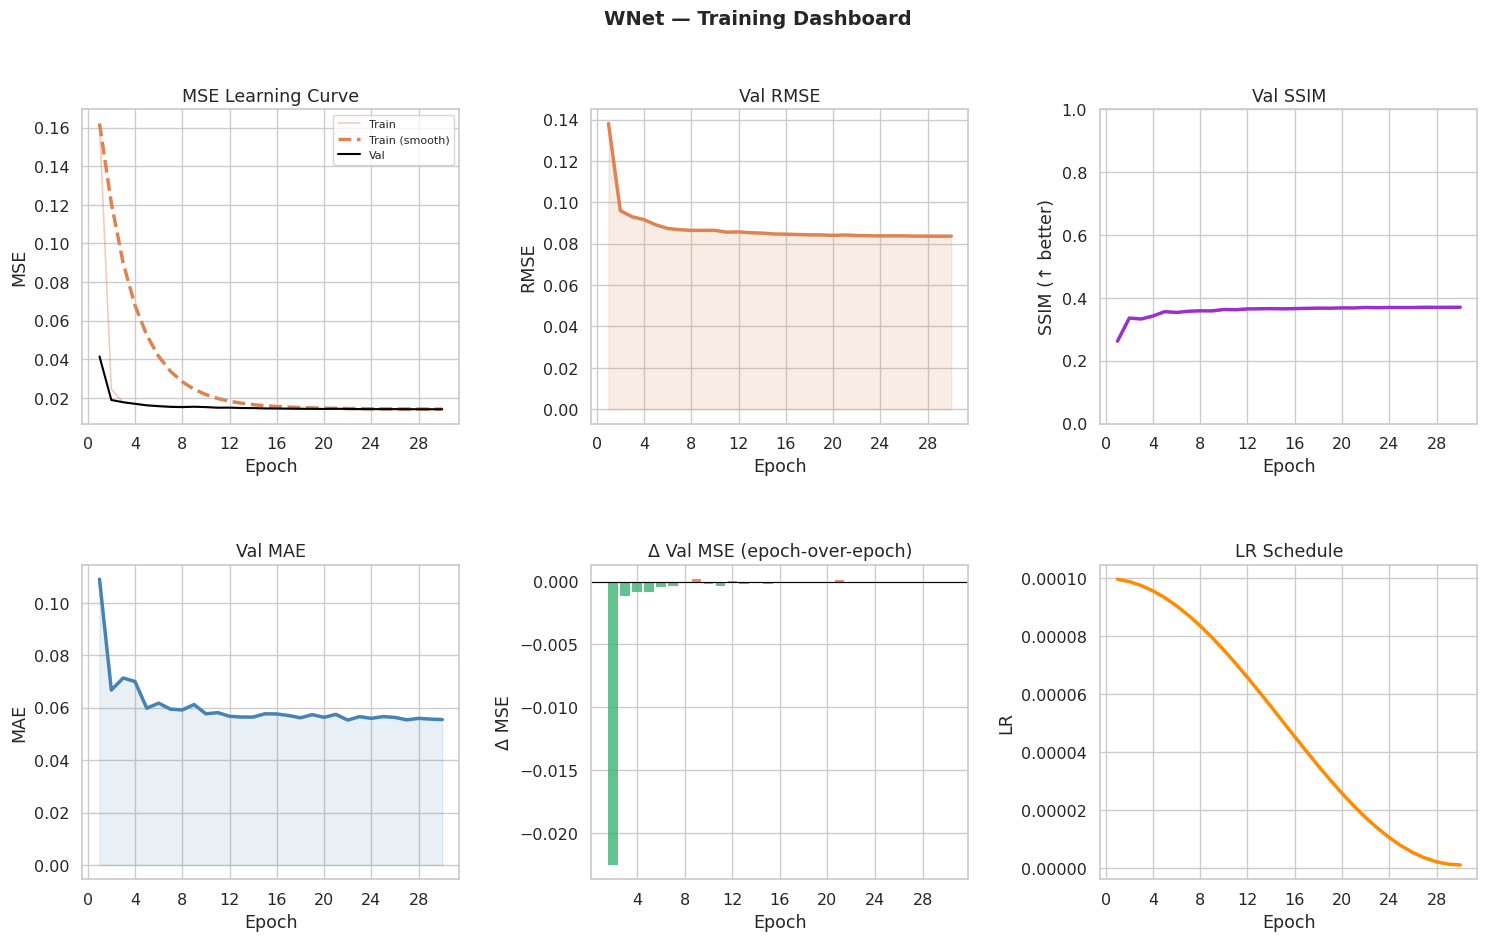

Saved: /content/drive/MyDrive/Senior Design/checkpoints/ablation/WNet_dashboard.png


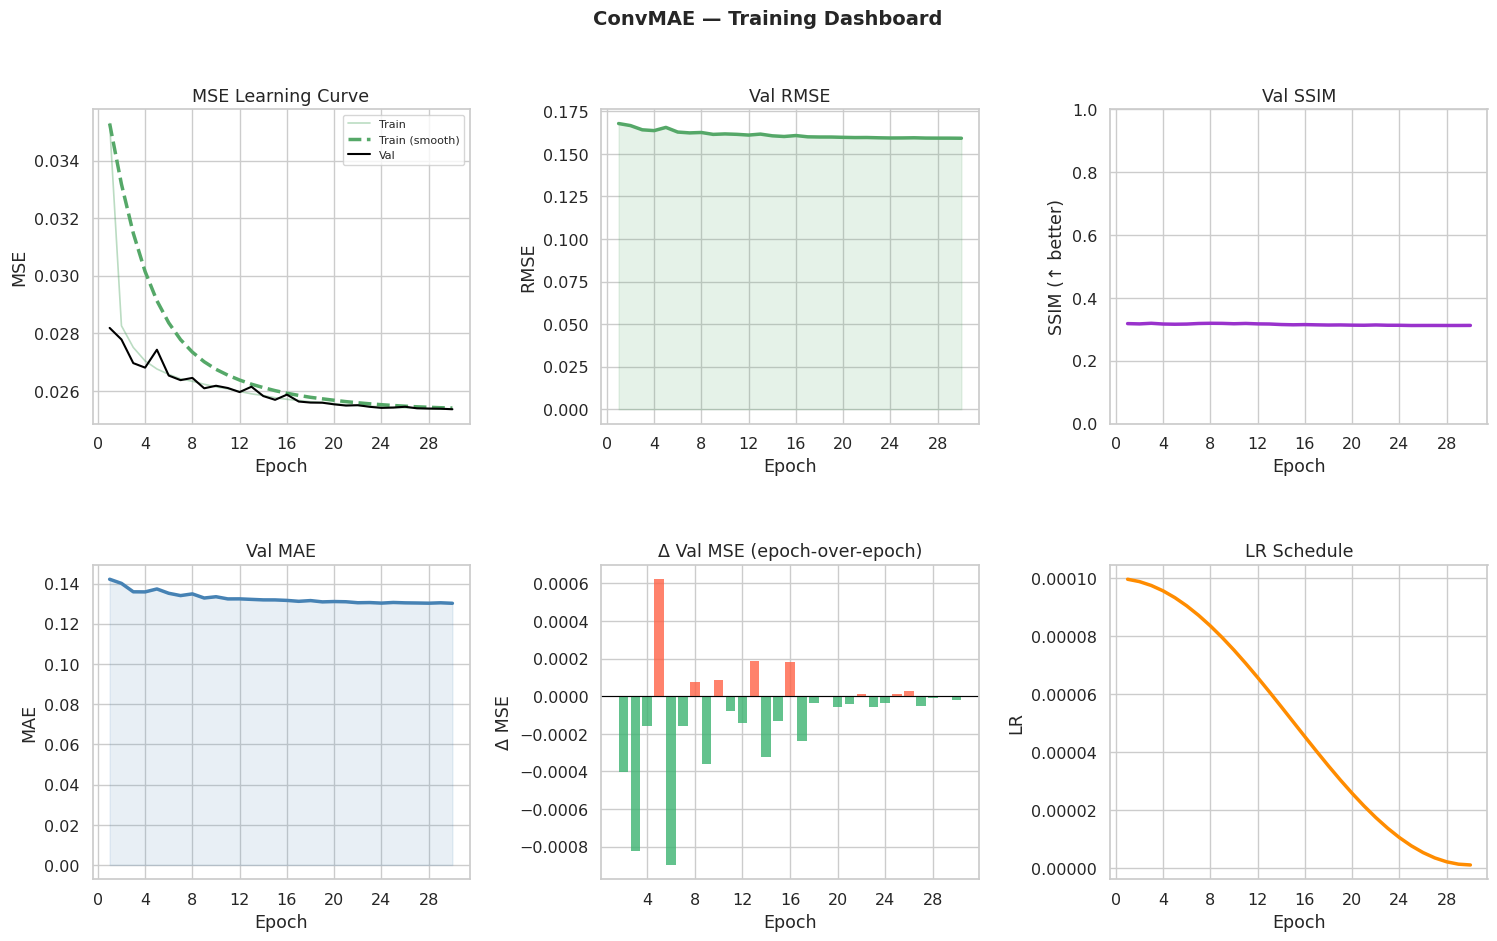

Saved: /content/drive/MyDrive/Senior Design/checkpoints/ablation/ConvMAE_dashboard.png


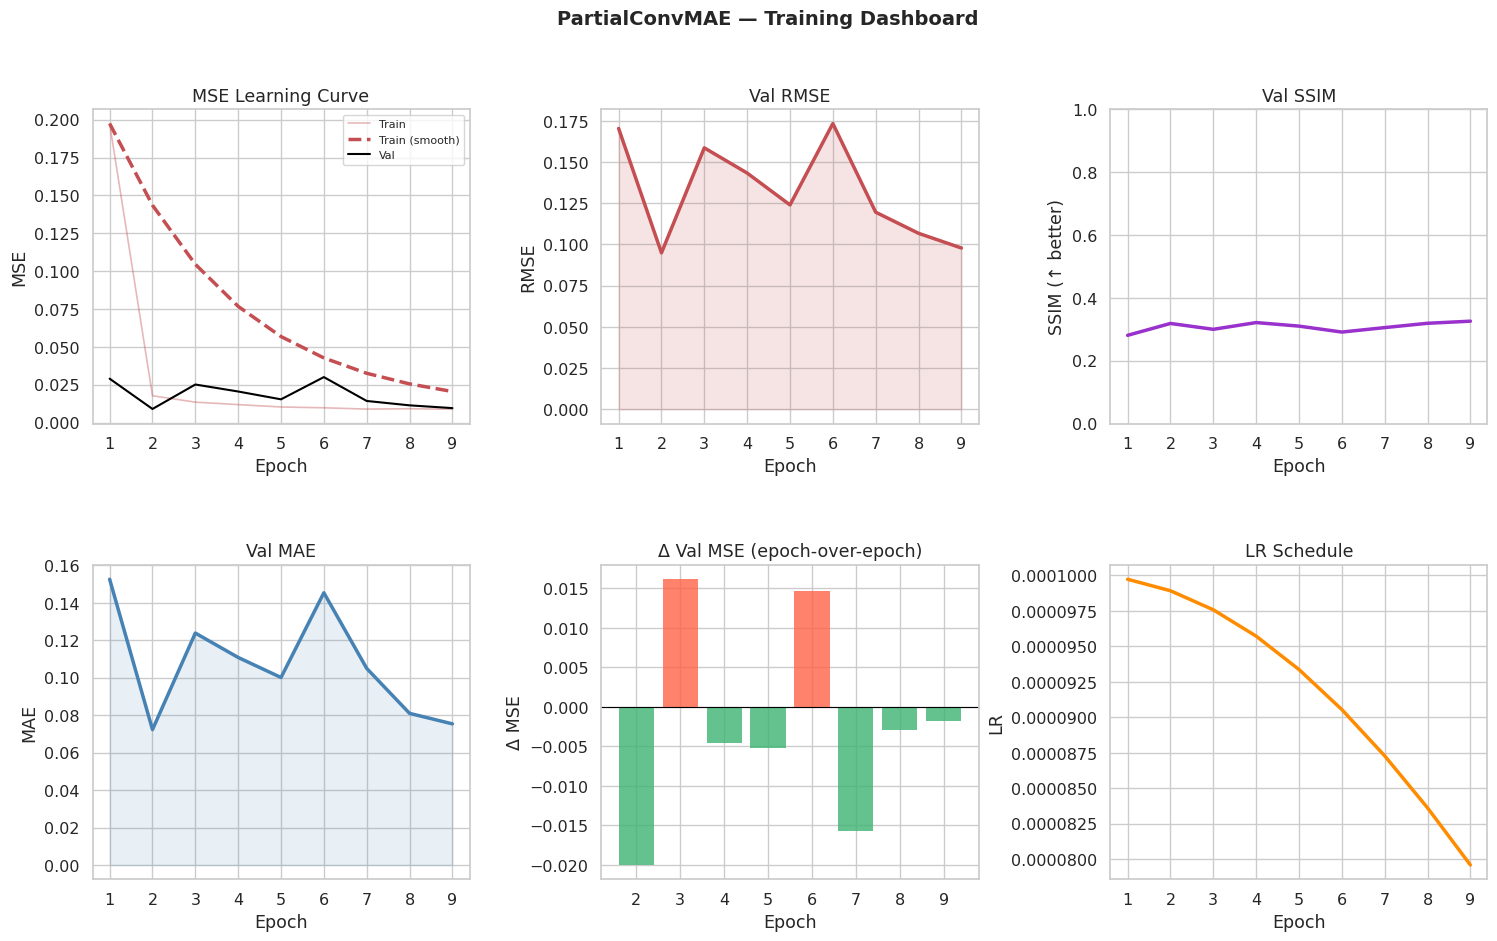

Saved: /content/drive/MyDrive/Senior Design/checkpoints/ablation/PartialConvMAE_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

def plot_model_dashboard(name, h, color):
    ep   = np.arange(1, len(h['train_loss']) + 1)
    tr_mse  = np.array(h['train_loss'])
    va_mse  = np.array(h['val_loss'])
    va_rmse = np.array(h.get('val_rmse', np.sqrt(va_mse)))
    va_mae  = np.array(h.get('val_mae',  va_rmse))
    va_ssim = np.array(h.get('val_ssim', np.ones_like(va_rmse)))
    lrs     = np.array(h.get('lr',      np.full_like(tr_mse, np.nan)))

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f'{name} — Training Dashboard', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

    # 1. MSE learning curve
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(ep, tr_mse, color=color, alpha=0.4, lw=1.2, label='Train')
    ax.plot(ep, ema(tr_mse), color=color, lw=2.5, linestyle='--', label='Train (smooth)')
    ax.plot(ep, va_mse, color='black', lw=1.5, label='Val')
    ax.set_title('MSE Learning Curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(fontsize=8); ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 2. Val RMSE
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(ep, va_rmse, color=color, lw=2.5)
    ax.fill_between(ep, va_rmse, alpha=0.15, color=color)
    ax.set_title('Val RMSE'); ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 3. Val SSIM
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(ep, va_ssim, color='darkorchid', lw=2.5)
    ax.set_title('Val SSIM'); ax.set_xlabel('Epoch'); ax.set_ylabel('SSIM (↑ better)')
    ax.set_ylim(0, 1); ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 4. Val MAE
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(ep, va_mae, color='steelblue', lw=2.5)
    ax.fill_between(ep, va_mae, alpha=0.12, color='steelblue')
    ax.set_title('Val MAE'); ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 5. Epoch-over-epoch Δ MSE
    ax = fig.add_subplot(gs[1, 1])
    if len(va_mse) > 1:
        d = np.diff(va_mse)
        ax.bar(ep[1:], d,
               color=['tomato' if v > 0 else 'mediumseagreen' for v in d],
               edgecolor='none', alpha=0.8)
        ax.axhline(0, color='black', lw=0.8)
    ax.set_title('Δ Val MSE (epoch-over-epoch)'); ax.set_xlabel('Epoch'); ax.set_ylabel('Δ MSE')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # 6. LR schedule
    ax = fig.add_subplot(gs[1, 2])
    if not np.all(np.isnan(lrs)):
        ax.plot(ep, lrs, color='darkorange', lw=2.5)
        ax.set_ylabel('LR')
    else:
        ax.text(0.5, 0.5, 'Not logged', ha='center', va='center',
                transform=ax.transAxes, color='grey')
    ax.set_title('LR Schedule'); ax.set_xlabel('Epoch')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    path = os.path.join(CKPT_DIR, f'{name}_dashboard.png')
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


for mname, h in all_histories.items():
    plot_model_dashboard(mname, h, MODEL_COLORS[mname])

## 10 · Inference Speed Benchmark

In [ ]:
import time

def benchmark_inference(model, device, img_size=IMG_SIZE, n_warmup=20, n_runs=200,
                        batch_sizes=(1, 4, 16, 32)):
    """
    Measures:
      - Single-sample latency (ms)  — AGV real-time critical metric
      - Throughput (samples/s) at each batch size
    """
    model.eval()
    results = {}

    for bs in batch_sizes:
        dummy = torch.rand(bs, 3, img_size, img_size, device=device)
        # Warm-up
        for _ in range(n_warmup):
            with torch.no_grad():
                out = model(dummy)
                if isinstance(out, (list, tuple)):
                    out = out[-1]
        if device.type == 'cuda':
            torch.cuda.synchronize()

        # Timed runs
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            with torch.no_grad():
                out = model(dummy)
                if isinstance(out, (list, tuple)):
                    out = out[-1]
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

        mean_s = np.mean(times)
        std_s  = np.std(times)
        latency_ms = (mean_s / bs) * 1000          # per-sample latency
        throughput  = bs / mean_s                   # samples/s
        results[bs] = {
            'mean_batch_s': mean_s,
            'std_batch_s' : std_s,
            'latency_ms'  : latency_ms,
            'throughput'  : throughput,
        }
    return results


speed_results = {}
model_map = {
    'CNN'           : cnn_model,
    'WNet'          : wnet_model,
    'ConvMAE'       : convmae_model,
    'PartialConvMAE': pconv_model,
}

for mname, mdl in model_map.items():
    print(f'Benchmarking {mname}...')
    speed_results[mname] = benchmark_inference(mdl, device)
    lat = speed_results[mname][1]['latency_ms']
    thr = speed_results[mname][1]['throughput']
    print(f'  BS=1 → {lat:.2f} ms/sample | {thr:.1f} samp/s')

print('\nSpeed benchmark complete.')

Benchmarking CNN...
  BS=1 → 4.50 ms/sample | 222.3 samp/s
Benchmarking WNet...
  BS=1 → 18.99 ms/sample | 52.7 samp/s
Benchmarking ConvMAE...
  BS=1 → 24.04 ms/sample | 41.6 samp/s
Benchmarking PartialConvMAE...
  BS=1 → 5.32 ms/sample | 188.0 samp/s

Speed benchmark complete.


## 11 · Test-Set Evaluation

In [ ]:
def evaluate_on_test(model, loader, device, wnet=False):
    model.eval()
    totals = defaultdict(float)
    n = 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(device), tgt.to(device)
            preds = model(inp)
            if isinstance(preds, (list, tuple)):
                preds = preds[-1]
            bs = inp.size(0)
            m  = compute_metrics_batch(preds, tgt)
            for k, v in m.items():
                totals[k] += v * bs
            n += bs
    return {k: v / n for k, v in totals.items()}


test_results = {}
for mname, mdl in model_map.items():
    wnet = (mname == 'WNet')
    res  = evaluate_on_test(mdl, test_loader, device, wnet=wnet)
    test_results[mname] = res
    print(f'{mname:18s}  MSE={res["mse"]:.5f}  RMSE={res["rmse"]:.4f}  '
          f'MAE={res["mae"]:.4f}  SSIM={res["ssim"]:.4f}')

# Build summary DataFrame
rows = []
for mname, res in test_results.items():
    row = {'Model': mname, **res}
    row['Params_M']          = count_params(model_map[mname]) / 1e6
    row['Latency_ms_BS1']    = speed_results[mname][1]['latency_ms']
    row['Throughput_BS32']   = speed_results[mname].get(32, {}).get('throughput', np.nan)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df = summary_df[['mse','rmse','mae','ssim','Params_M','Latency_ms_BS1','Throughput_BS32']]
summary_df.columns = ['MSE','RMSE','MAE','SSIM','Params (M)','Latency ms (BS=1)','Throughput (samp/s, BS=32)']
print('\n── Test-Set Summary ──')
print(summary_df.round(4).to_string())

csv_path = os.path.join(CKPT_DIR, 'ablation_summary.csv')
summary_df.to_csv(csv_path)
print(f'\nSaved: {csv_path}')

CNN                 MSE=0.00694  RMSE=0.0833  MAE=0.0546  SSIM=0.3715
WNet                MSE=0.00700  RMSE=0.0836  MAE=0.0556  SSIM=0.3703
ConvMAE             MSE=0.02529  RMSE=0.1590  MAE=0.1299  SSIM=0.3129
PartialConvMAE      MSE=0.00898  RMSE=0.0947  MAE=0.0720  SSIM=0.3191

── Test-Set Summary ──
                   MSE    RMSE     MAE    SSIM  Params (M)  Latency ms (BS=1)  Throughput (samp/s, BS=32)
Model                                                                                                    
CNN             0.0069  0.0833  0.0546  0.3715      1.5620             4.4987                    235.0650
WNet            0.0070  0.0836  0.0556  0.3703     13.2753            18.9898                    102.2683
ConvMAE         0.0253  0.1590  0.1299  0.3129    115.3798            24.0387                     45.5765
PartialConvMAE  0.0090  0.0947  0.0720  0.3191      1.5613             5.3188                    206.3373

Saved: /content/drive/MyDrive/Senior Design/checkpoints/abl

## 12 · Cross-Model Comparison Plots

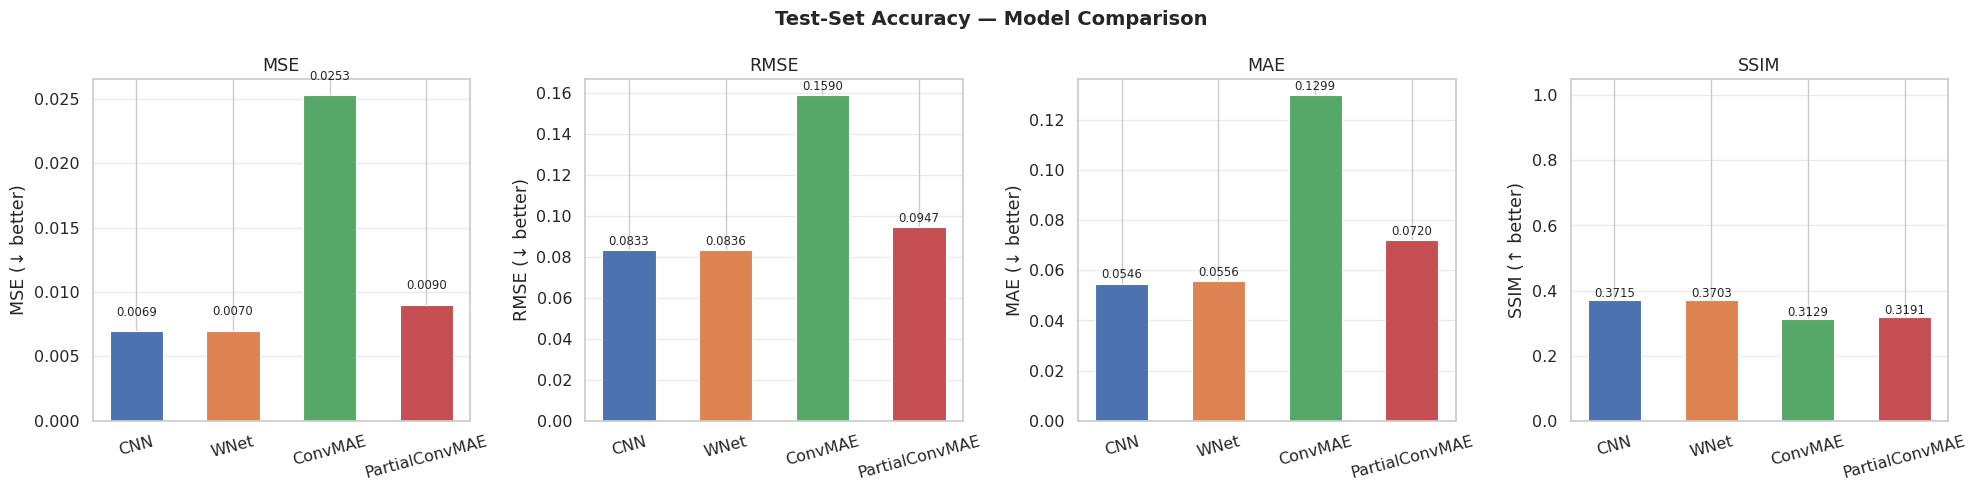

In [ ]:
# ── 12a. Bar charts: MSE / RMSE / MAE / SSIM ─────────────────
metrics_to_plot = ['MSE', 'RMSE', 'MAE', 'SSIM']
n_metrics = len(metrics_to_plot)
models    = summary_df.index.tolist()
colors    = [MODEL_COLORS[m] for m in models]

fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
fig.suptitle('Test-Set Accuracy — Model Comparison', fontsize=14, fontweight='bold')

for ax, met in zip(axes, metrics_to_plot):
    vals = summary_df[met].values
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=0.8, width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_title(met)
    ax.set_ylabel(met + (' (↑ better)' if met == 'SSIM' else ' (↓ better)'))
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.4)
    if met == 'SSIM':
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_accuracy_bars.png'), dpi=130, bbox_inches='tight')
plt.show()

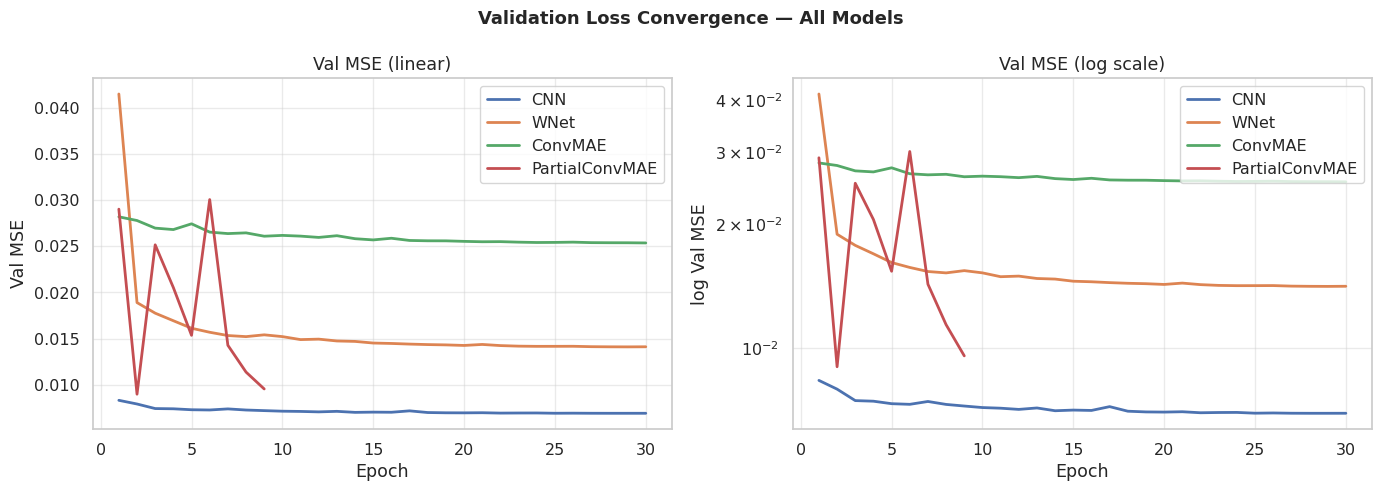

In [ ]:
# ── 12b. Training curves overlay (val MSE) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validation Loss Convergence — All Models', fontsize=13, fontweight='bold')

for mname, h in all_histories.items():
    c  = MODEL_COLORS[mname]
    ep = np.arange(1, len(h['val_loss']) + 1)
    va = np.array(h['val_loss'])
    axes[0].plot(ep, va, color=c, lw=2, label=mname)
    axes[1].semilogy(ep, va, color=c, lw=2, label=mname)

axes[0].set_title('Val MSE (linear)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_title('Val MSE (log scale)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('log Val MSE')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_val_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

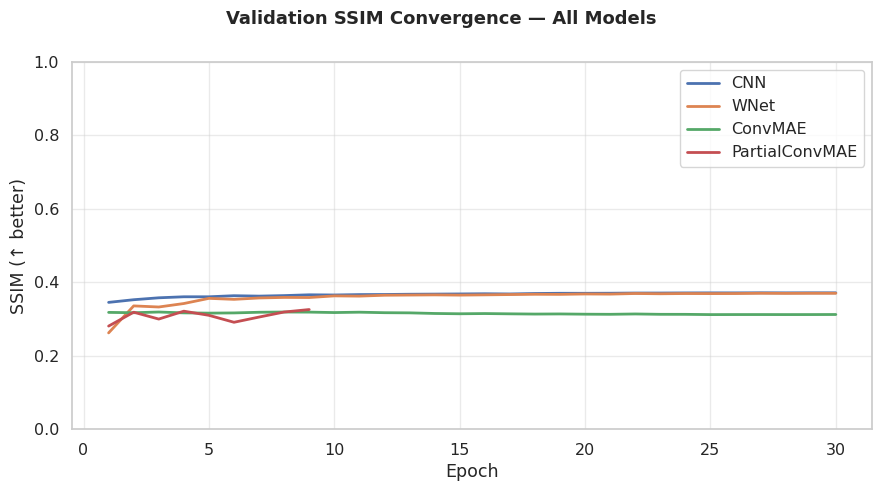

In [ ]:
# ── 12c. SSIM convergence overlay ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Validation SSIM Convergence — All Models', fontsize=13, fontweight='bold')

for mname, h in all_histories.items():
    if 'val_ssim' not in h:
        continue
    c  = MODEL_COLORS[mname]
    ep = np.arange(1, len(h['val_ssim']) + 1)
    ax.plot(ep, h['val_ssim'], color=c, lw=2, label=mname)

ax.set_xlabel('Epoch'); ax.set_ylabel('SSIM (↑ better)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_ssim_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

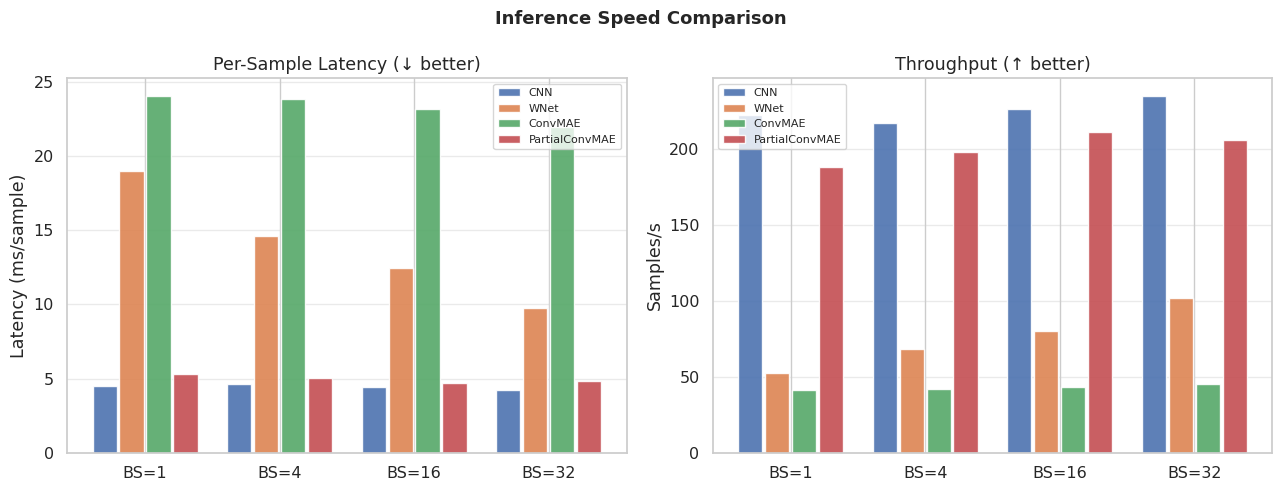

In [ ]:
# ── 12d. Latency & throughput comparison ────────────────────
bs_list = [1, 4, 16, 32]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Inference Speed Comparison', fontsize=13, fontweight='bold')

x = np.arange(len(bs_list))
width = 0.2

for i, (mname, sr) in enumerate(speed_results.items()):
    lats = [sr[bs]['latency_ms']  for bs in bs_list if bs in sr]
    thrs = [sr[bs]['throughput']  for bs in bs_list if bs in sr]
    bsf  = [bs for bs in bs_list if bs in sr]
    xs   = np.arange(len(bsf)) + i * width
    axes[0].bar(xs, lats, width=width*0.9, color=MODEL_COLORS[mname], label=mname, alpha=0.9)
    axes[1].bar(xs, thrs, width=width*0.9, color=MODEL_COLORS[mname], label=mname, alpha=0.9)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels([f'BS={b}' for b in bs_list])
axes[0].set_title('Per-Sample Latency (↓ better)')
axes[0].set_ylabel('Latency (ms/sample)'); axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.4)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([f'BS={b}' for b in bs_list])
axes[1].set_title('Throughput (↑ better)')
axes[1].set_ylabel('Samples/s'); axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_speed.png'), dpi=130, bbox_inches='tight')
plt.show()

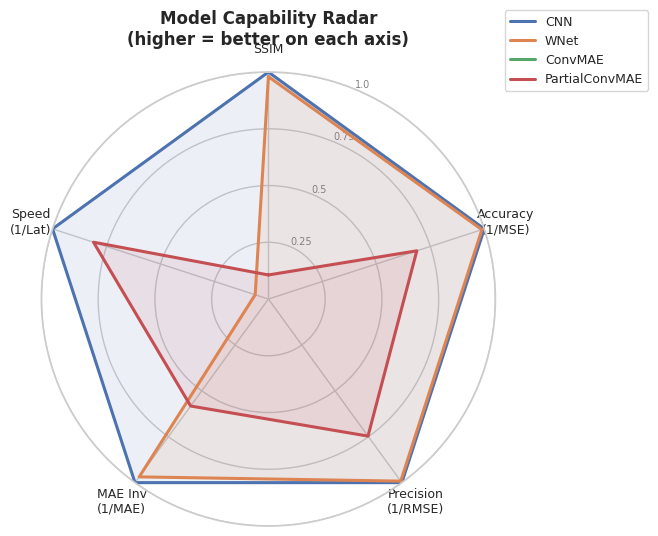

In [ ]:
# ── 12e. Radar / spider chart — accuracy vs speed tradeoff ───
from matplotlib.patches import FancyArrowPatch
import matplotlib

def radar_chart(df, title, save_path):
    """Normalised radar chart across five dimensions."""
    # Five axes: SSIM (↑), 1/MSE (↑), 1/RMSE (↑), 1/MAE (↑), 1/Latency (↑)
    cats = ['SSIM', 'Accuracy\n(1/MSE)', 'Precision\n(1/RMSE)',
            'MAE Inv\n(1/MAE)', 'Speed\n(1/Lat)']
    N = len(cats)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=9)

    # Build raw values per model
    raw = {}
    for m in df.index:
        raw[m] = [
            df.loc[m,'SSIM'],
            1.0 / (df.loc[m,'MSE']  + 1e-9),
            1.0 / (df.loc[m,'RMSE'] + 1e-9),
            1.0 / (df.loc[m,'MAE']  + 1e-9),
            1.0 / (df.loc[m,'Latency ms (BS=1)'] + 1e-9),
        ]

    # Normalise each axis to [0,1] across models
    raw_arr = np.array([raw[m] for m in df.index])   # (n_models, 5)
    mn  = raw_arr.min(axis=0)
    mx  = raw_arr.max(axis=0)
    norm_arr = (raw_arr - mn) / (mx - mn + 1e-12)

    for i, m in enumerate(df.index):
        vals = norm_arr[i].tolist() + [norm_arr[i][0]]
        ax.plot(angles, vals, color=MODEL_COLORS[m], lw=2.2, label=m)
        ax.fill(angles, vals, color=MODEL_COLORS[m], alpha=0.10)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.5','0.75','1.0'], size=7, color='grey')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.set_title(title, size=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

radar_chart(summary_df, 'Model Capability Radar\n(higher = better on each axis)',
            os.path.join(CKPT_DIR, 'compare_radar.png'))

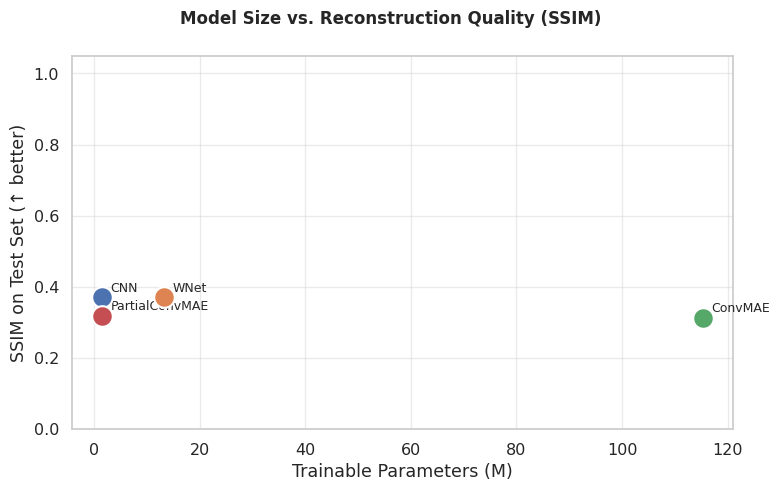

In [ ]:
# ── 12g. Params vs SSIM bubble chart ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Model Size vs. Reconstruction Quality (SSIM)',
             fontsize=12, fontweight='bold')

for m in summary_df.index:
    p = summary_df.loc[m, 'Params (M)']
    s = summary_df.loc[m, 'SSIM']
    ax.scatter(p, s, s=220, color=MODEL_COLORS[m], edgecolors='white',
               linewidths=1.5, zorder=5)
    ax.annotate(m, (p, s), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Trainable Parameters (M)')
ax.set_ylabel('SSIM on Test Set (↑ better)')
ax.set_ylim(0, 1.05); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_params_ssim.png'), dpi=130, bbox_inches='tight')
plt.show()

## 13 · Qualitative Reconstruction Comparison

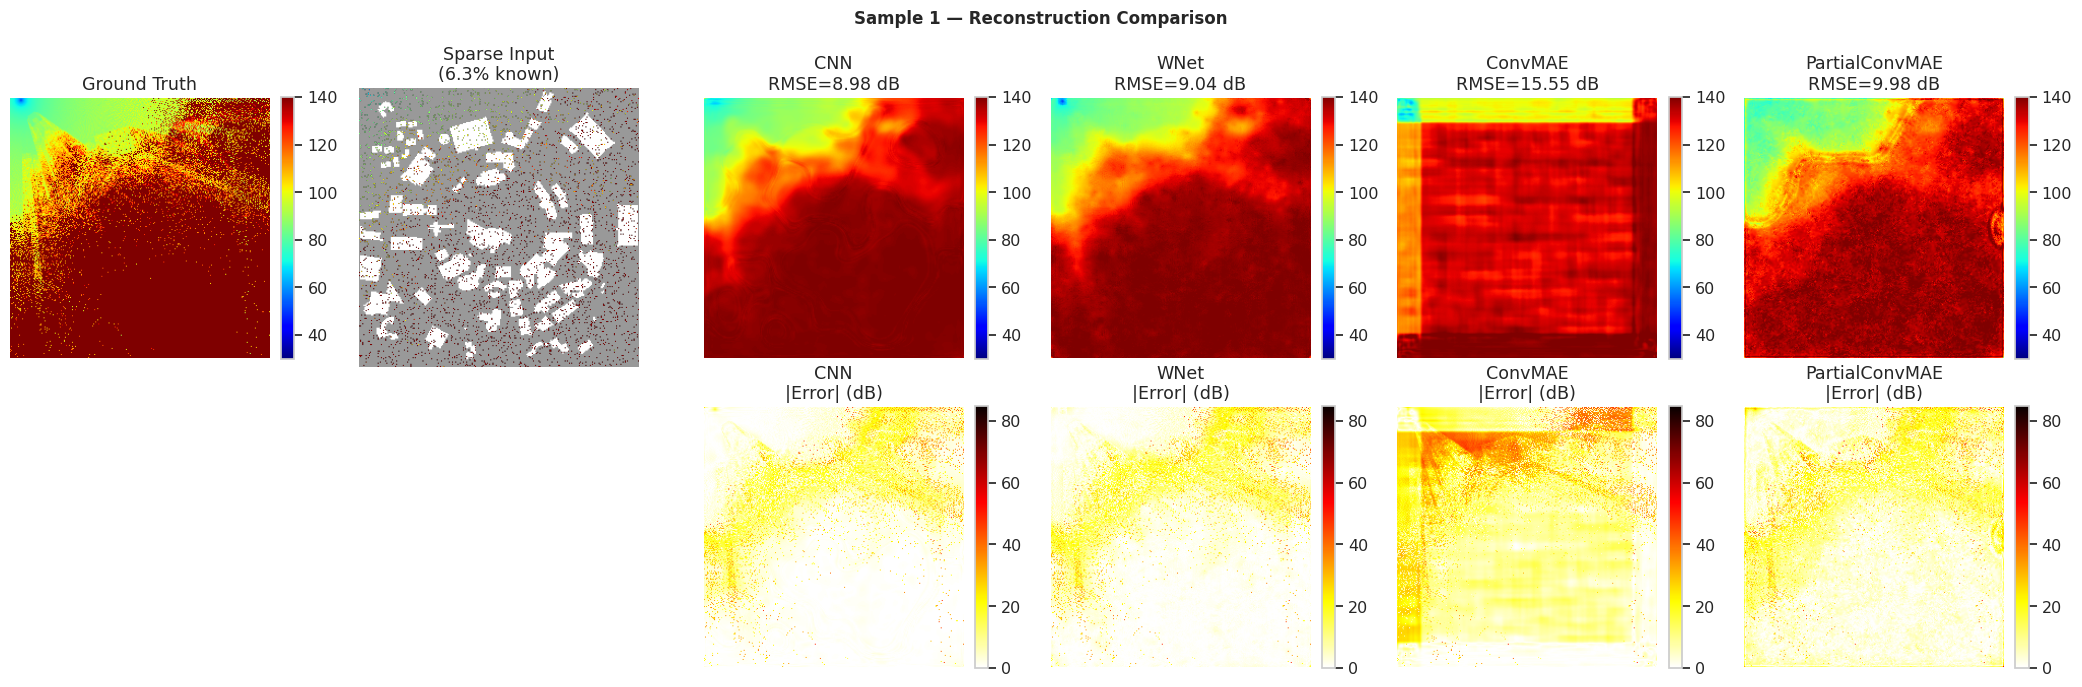

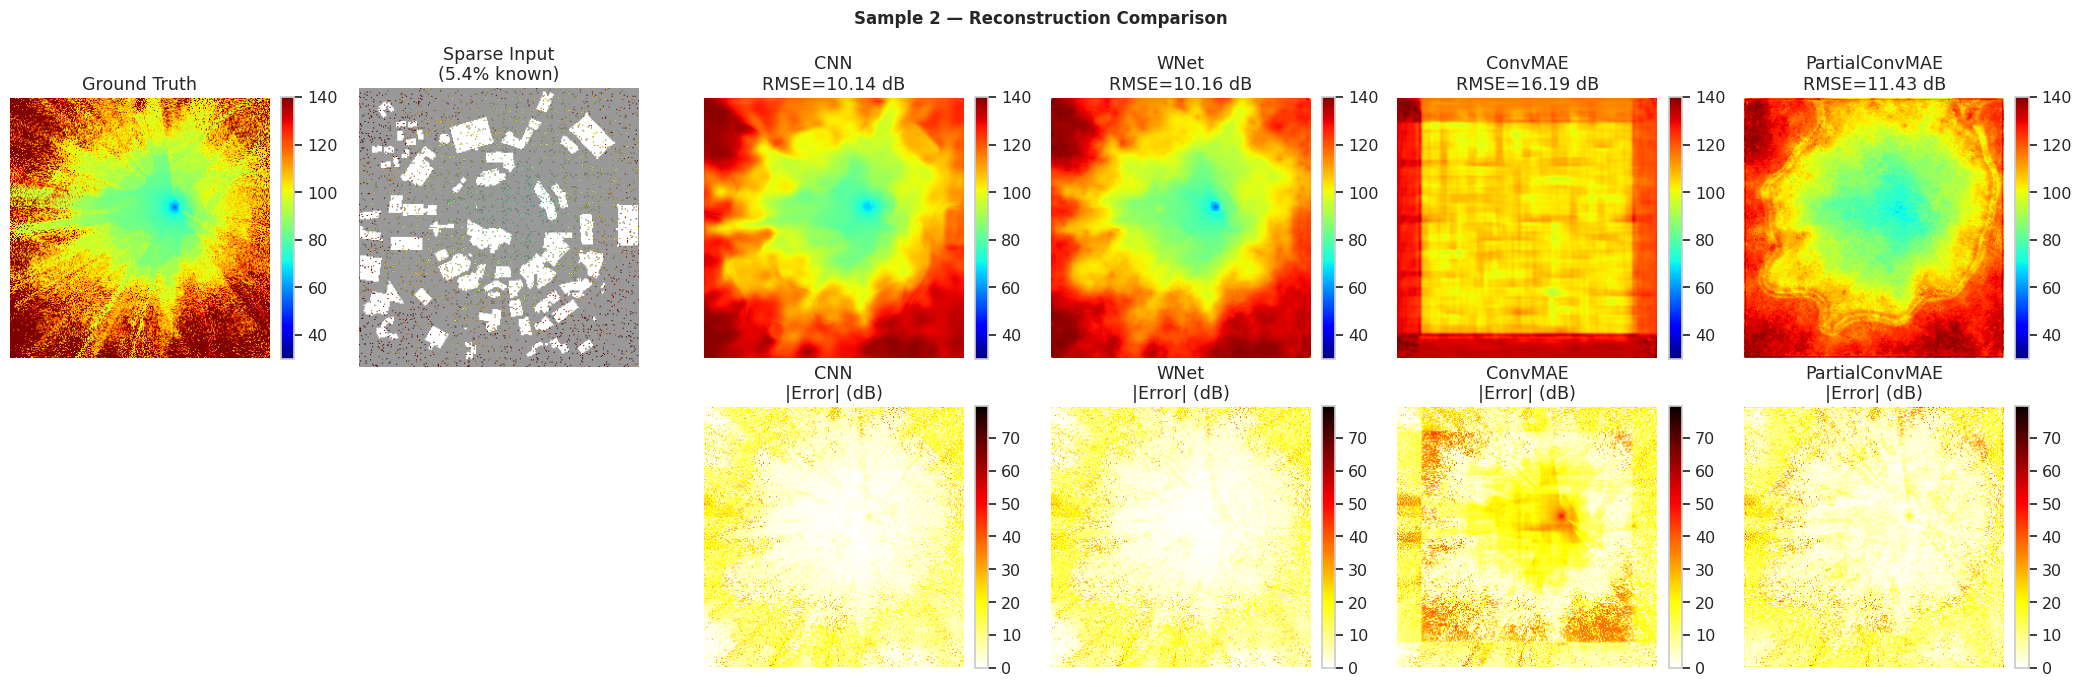

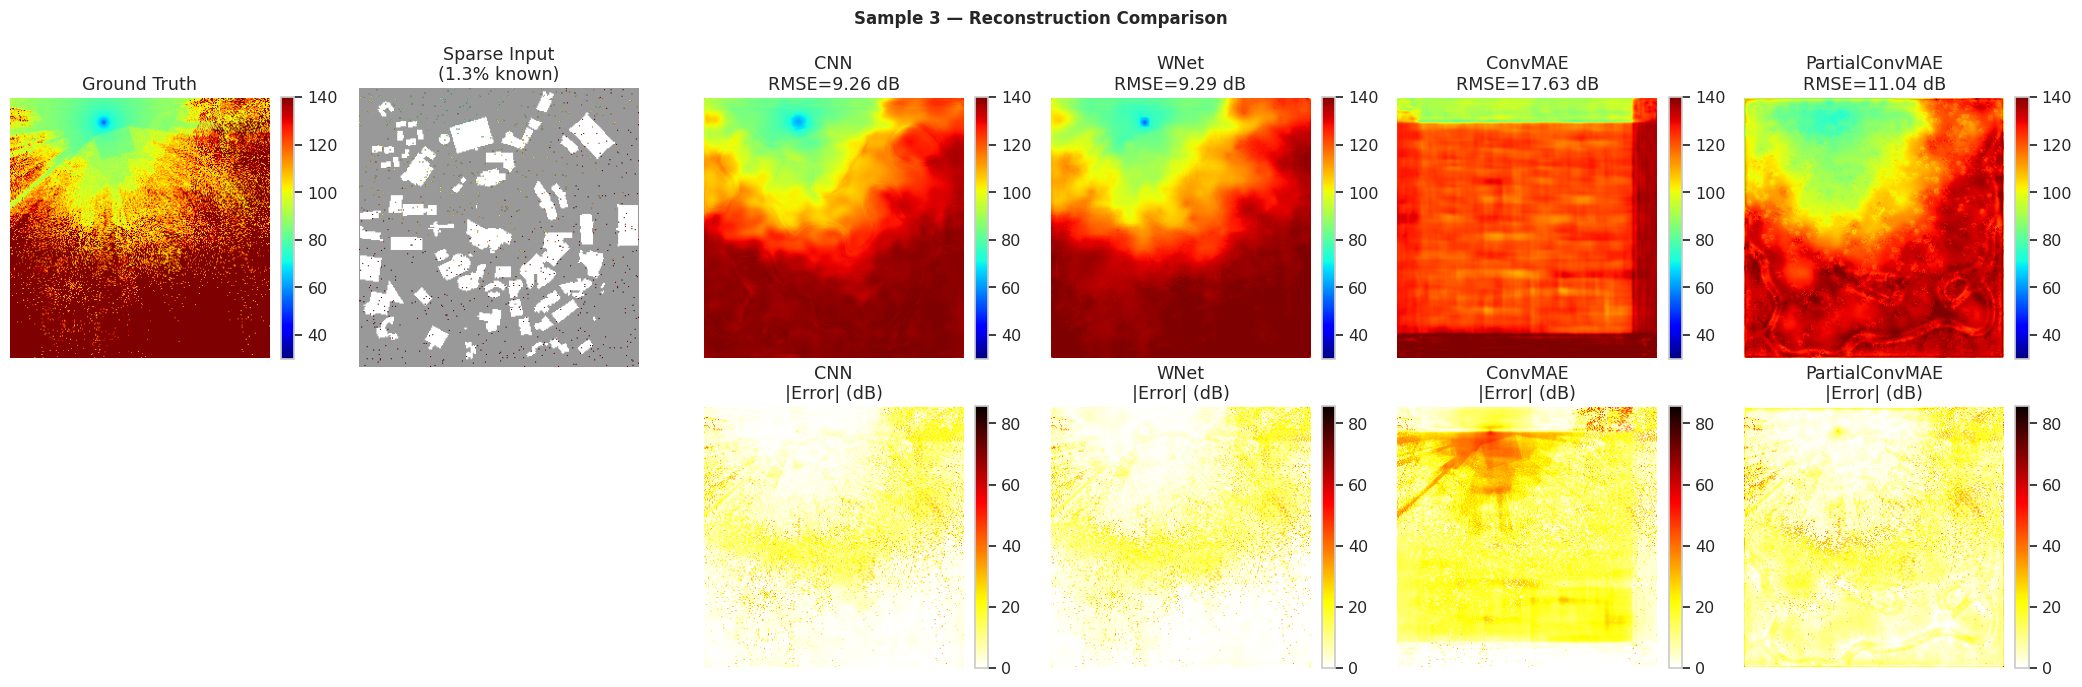

In [ ]:
def qualitative_comparison(model_map, test_loader, device, n_samples=3,
                           min_db=MIN_DB, max_db=MAX_DB):
    """
    For n_samples from the test set, shows:
      Ground truth | Sparse input | CNN | WNet | ConvMAE | PartialConvMAE
    + error maps
    """
    for mdl in model_map.values():
        mdl.eval()

    inputs_batch, targets_batch = next(iter(test_loader))
    inputs_batch = inputs_batch[:n_samples].to(device)
    targets_batch= targets_batch[:n_samples].to(device)

    preds = {}
    with torch.no_grad():
        for mname, mdl in model_map.items():
            out = mdl(inputs_batch)
            if isinstance(out, (list, tuple)):
                out = out[-1]
            preds[mname] = out.cpu().numpy()

    inp_np  = inputs_batch.cpu().numpy()
    tgt_np  = targets_batch.cpu().numpy()
    db_range = max_db - min_db

    model_names = list(model_map.keys())
    n_cols = 2 + len(model_names)   # gt + sparse + models

    for i in range(n_samples):
        fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7))
        fig.suptitle(f'Sample {i+1} — Reconstruction Comparison', fontsize=12, fontweight='bold')

        tgt_db = tgt_np[i, 0] * db_range + min_db
        vmin, vmax = min_db, max_db

        # Ground truth
        im = axes[0, 0].imshow(tgt_db, cmap='jet', vmin=vmin, vmax=vmax)
        axes[0, 0].set_title('Ground Truth'); axes[0, 0].axis('off')
        plt.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

        # Sparse input
        sparse_norm = inp_np[i, 2]
        sparse_db   = np.where(sparse_norm > 0, sparse_norm * db_range + min_db, np.nan)
        axes[0, 1].imshow(inp_np[i, 0], cmap='gray', alpha=0.4)
        im2 = axes[0, 1].imshow(sparse_db, cmap='jet', vmin=vmin, vmax=vmax)
        pct = np.sum(~np.isnan(sparse_db)) / (IMG_SIZE**2) * 100
        axes[0, 1].set_title(f'Sparse Input\n({pct:.1f}% known)')
        axes[0, 1].axis('off')

        # Predictions
        for j, mname in enumerate(model_names):
            pred_db = preds[mname][i, 0] * db_range + min_db
            err_db  = np.abs(pred_db - tgt_db)
            rmse_s  = np.sqrt(np.mean((pred_db - tgt_db) ** 2))
            im_p = axes[0, 2+j].imshow(pred_db, cmap='jet', vmin=vmin, vmax=vmax)
            axes[0, 2+j].set_title(f'{mname}\nRMSE={rmse_s:.2f} dB')
            axes[0, 2+j].axis('off')
            plt.colorbar(im_p, ax=axes[0, 2+j], fraction=0.046, pad=0.04)

        # ── Row 2: error maps ─────────────────────────────────
        axes[1, 0].axis('off')  # blank
        axes[1, 1].axis('off')  # blank
        emax = max(np.abs(preds[m][i,0]*db_range - tgt_db).max() for m in model_names)
        for j, mname in enumerate(model_names):
            pred_db = preds[mname][i, 0] * db_range + min_db
            err_db  = np.abs(pred_db - tgt_db)
            im_e = axes[1, 2+j].imshow(err_db, cmap='hot_r', vmin=0, vmax=emax)
            axes[1, 2+j].set_title(f'{mname}\n|Error| (dB)')
            axes[1, 2+j].axis('off')
            plt.colorbar(im_e, ax=axes[1, 2+j], fraction=0.046, pad=0.04)

        plt.tight_layout()
        path = os.path.join(CKPT_DIR, f'qualitative_sample_{i+1}.png')
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()

qualitative_comparison(model_map, test_loader, device)

## 14 · Error Distribution Analysis

Residuals collected.


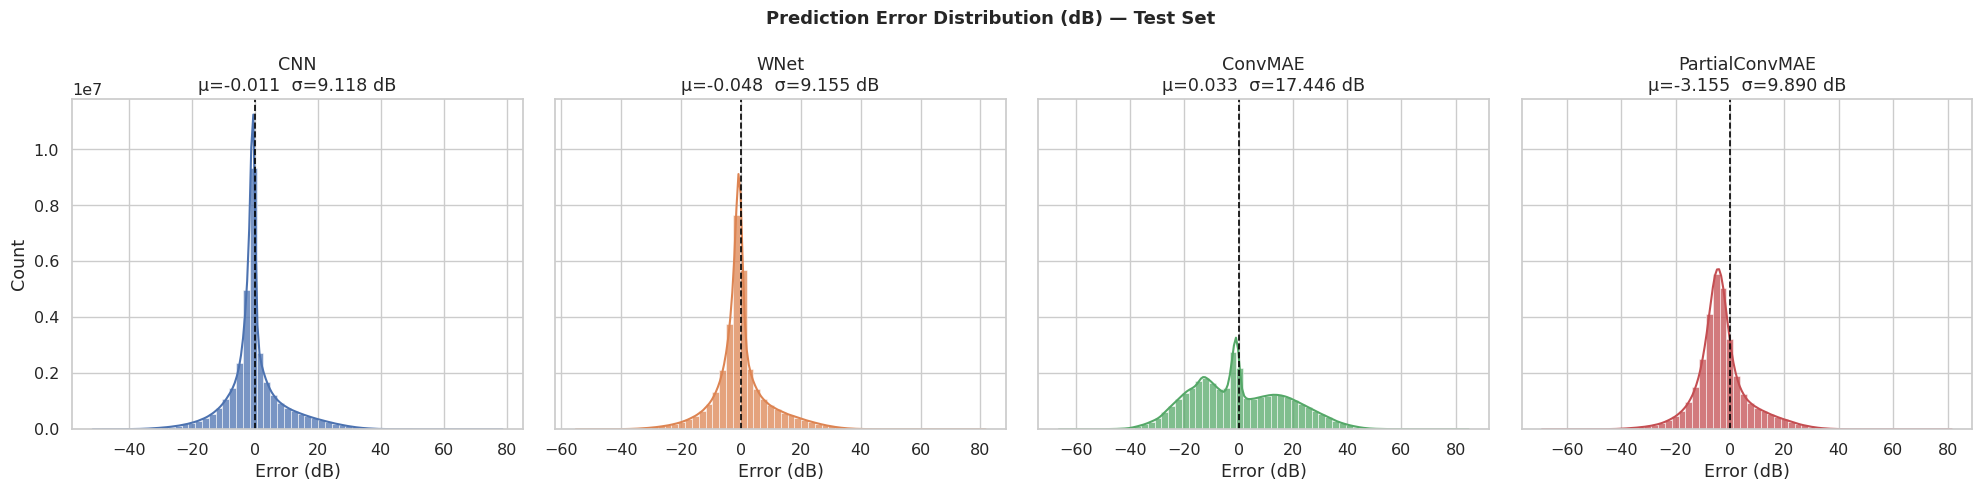

In [ ]:
# Collect all residuals (unnormalised, in dB) for a subset of the test set
N_DIST_SAMPLES = min(500, len(test_ds))
sub_loader = DataLoader(
    torch.utils.data.Subset(test_ds, list(range(N_DIST_SAMPLES))),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

residuals_db = {m: [] for m in model_map}

for inp, tgt in sub_loader:
    inp, tgt = inp.to(device), tgt.to(device)
    with torch.no_grad():
        for mname, mdl in model_map.items():
            out = mdl(inp)
            if isinstance(out, (list, tuple)):
                out = out[-1]
            err = ((out - tgt) * (MAX_DB - MIN_DB)).cpu().numpy().flatten()
            residuals_db[mname].append(err)

for m in model_map:
    residuals_db[m] = np.concatenate(residuals_db[m])

print('Residuals collected.')

# ── Error histograms ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(model_map), figsize=(5 * len(model_map), 5), sharey=True)
fig.suptitle('Prediction Error Distribution (dB) — Test Set', fontsize=13, fontweight='bold')

for ax, (mname, errs) in zip(axes, residuals_db.items()):
    sns.histplot(errs, bins=60, kde=True, ax=ax, color=MODEL_COLORS[mname], alpha=0.75)
    ax.axvline(0, color='black', lw=1.2, linestyle='--')
    ax.set_title(f'{mname}\nμ={errs.mean():.3f}  σ={errs.std():.3f} dB')
    ax.set_xlabel('Error (dB)'); ax.set_ylabel('Count' if ax == axes[0] else '')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_error_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()

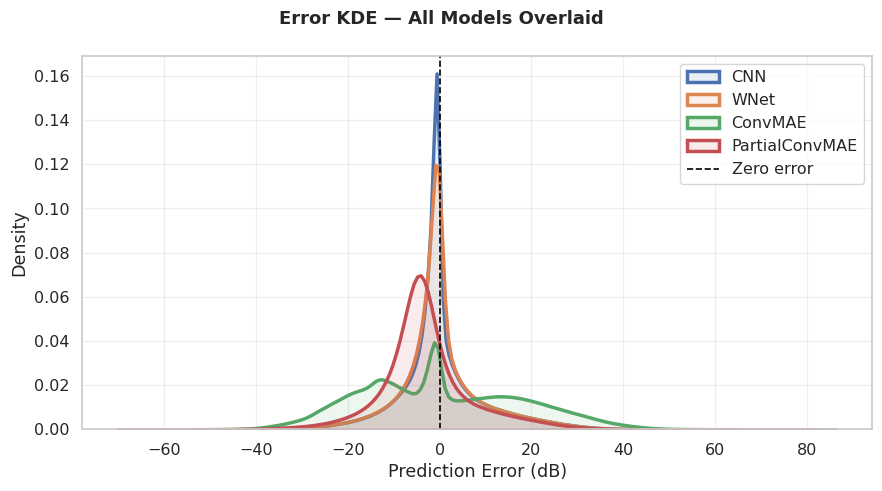

In [ ]:
# ── Overlaid KDE ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Error KDE — All Models Overlaid', fontsize=13, fontweight='bold')

for mname, errs in residuals_db.items():
    sns.kdeplot(errs, ax=ax, color=MODEL_COLORS[mname], lw=2.5, label=mname, fill=True, alpha=0.10)

ax.axvline(0, color='black', lw=1.2, linestyle='--', label='Zero error')
ax.set_xlabel('Prediction Error (dB)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_kde_overlay.png'), dpi=130, bbox_inches='tight')
plt.show()

/tmp/ipykernel_15519/2405322984.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, notch=False,


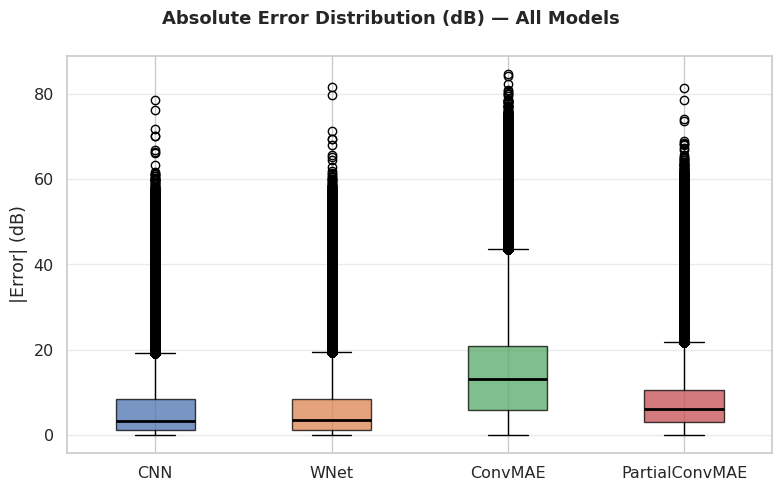

In [ ]:
# ── Box plot of absolute errors ───────────────────────────────
abs_err_data = {m: np.abs(r) for m, r in residuals_db.items()}
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Absolute Error Distribution (dB) — All Models', fontsize=13, fontweight='bold')

bp_data   = [abs_err_data[m] for m in model_map]
bp_labels = list(model_map.keys())
bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, notch=False,
                medianprops={'color':'black','lw':2})
for patch, m in zip(bp['boxes'], model_map.keys()):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.75)

ax.set_ylabel('|Error| (dB)'); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'compare_boxplot_abs_error.png'), dpi=130, bbox_inches='tight')
plt.show()

## 15 · Final Summary Table & AGV Recommendation

In [ ]:
print('\n' + '='*72)
print('  ABLATION STUDY — FINAL SUMMARY')
print('='*72)
print(summary_df.round(4).to_string())
print()

# Compute a simple composite AGV score:
#   60% accuracy weight  (inverse RMSE, normalised)
#   25% speed weight     (inverse latency, normalised)
#   15% SSIM weight
W_ACC   = 0.60
W_SPEED = 0.25
W_SSIM  = 0.15

rmse_inv = 1.0 / (summary_df['RMSE']           + 1e-9)
lat_inv  = 1.0 / (summary_df['Latency ms (BS=1)'] + 1e-9)
ssim_raw = summary_df['SSIM']

def norm01(s): return (s - s.min()) / (s.max() - s.min() + 1e-12)

score = W_ACC * norm01(rmse_inv) + W_SPEED * norm01(lat_inv) + W_SSIM * norm01(ssim_raw)
summary_df['AGV Score'] = score.round(4)

print('AGV Composite Score  (60% accuracy · 25% speed · 15% SSIM):')
print(summary_df[['RMSE','Latency ms (BS=1)','SSIM','AGV Score']]
      .sort_values('AGV Score', ascending=False).round(4).to_string())

best_model = summary_df['AGV Score'].idxmax()
print(f'\n  Recommended for AGV deployment: {best_model}')
print('='*72)

summary_df.to_csv(os.path.join(CKPT_DIR, 'ablation_summary_final.csv'))
print(f'\nFinal summary saved to: {CKPT_DIR}/ablation_summary_final.csv')


  ABLATION STUDY — FINAL SUMMARY
                   MSE    RMSE     MAE    SSIM  Params (M)  Latency ms (BS=1)  Throughput (samp/s, BS=32)
Model                                                                                                    
CNN             0.0069  0.0833  0.0546  0.3715      1.5620             4.4987                    235.0650
WNet            0.0070  0.0836  0.0556  0.3703     13.2753            18.9898                    102.2683
ConvMAE         0.0253  0.1590  0.1299  0.3129    115.3798            24.0387                     45.5765
PartialConvMAE  0.0090  0.0947  0.0720  0.3191      1.5613             5.3188                    206.3373

AGV Composite Score  (60% accuracy · 25% speed · 15% SSIM):
                  RMSE  Latency ms (BS=1)    SSIM  AGV Score
Model                                                       
CNN             0.0833             4.4987  0.3715     1.0000
WNet            0.0836            18.9898  0.3703     0.7573
PartialConvMAE  0.0947   

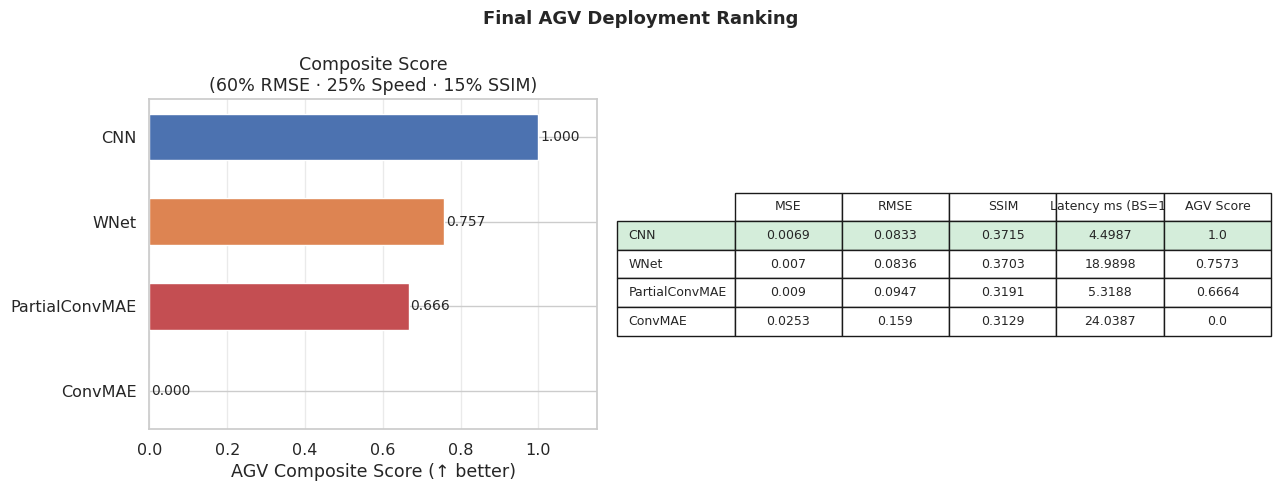

All figures saved to: /content/drive/MyDrive/Senior Design/checkpoints/ablation


In [ ]:
# ── Final ranking bar chart with AGV score ────────────────────
ranked = summary_df.sort_values('AGV Score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Final AGV Deployment Ranking', fontsize=13, fontweight='bold')

colors_ranked = [MODEL_COLORS[m] for m in ranked.index]

bars = axes[0].barh(ranked.index, ranked['AGV Score'], color=colors_ranked,
                    edgecolor='white', height=0.55)
for b, v in zip(bars, ranked['AGV Score']):
    axes[0].text(b.get_width() + 0.005, b.get_y() + b.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=10)
axes[0].set_xlabel('AGV Composite Score (↑ better)')
axes[0].set_title('Composite Score\n(60% RMSE · 25% Speed · 15% SSIM)')
axes[0].set_xlim(0, 1.15); axes[0].grid(axis='x', alpha=0.4)
axes[0].invert_yaxis()

# Table of all key metrics
axes[1].axis('off')
tbl_data = ranked[['MSE','RMSE','SSIM','Latency ms (BS=1)','AGV Score']].round(4)
tbl = axes[1].table(
    cellText=tbl_data.values,
    colLabels=tbl_data.columns,
    rowLabels=tbl_data.index,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.0)

# Highlight best row
for j in range(len(tbl_data.columns) + 1):
    tbl[1, j - 1].set_facecolor('#d4edda')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'final_ranking.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'All figures saved to: {CKPT_DIR}')

## 16 · All Generated Artefacts

| File | Description |
|------|-------------|
| `ablation_summary_final.csv` | Full test-set metrics + AGV composite score |
| `{MODEL}_history.csv` | Per-epoch train/val metrics for each model |
| `{MODEL}_best.pth` | Best checkpoint for each model |
| `{MODEL}_dashboard.png` | 6-panel per-model training dashboard |
| `compare_accuracy_bars.png` | Side-by-side bar chart: MSE/RMSE/MAE/SSIM |
| `compare_val_curves.png` | Overlaid val-MSE convergence (linear + log) |
| `compare_ssim_curves.png` | Overlaid val-SSIM curves |
| `compare_speed.png` | Latency & throughput at 4 batch sizes |
| `compare_radar.png` | Spider/radar capability chart |
| `compare_tradeoff_scatter.png` | RMSE vs Latency Pareto scatter |
| `compare_params_ssim.png` | Model size vs. SSIM bubble chart |
| `qualitative_sample_{N}.png` | Prediction + error map comparison per sample |
| `compare_error_distributions.png` | Per-model error histograms (dB) |
| `compare_kde_overlay.png` | Overlaid error KDE |
| `compare_boxplot_abs_error.png` | Absolute error box plots |
| `final_ranking.png` | Ranked bar chart + metrics table |

---
*Ablation study complete. The recommended model for AGV deployment is highlighted in the final ranking plot above.*